## Setup

In [50]:
#importing packages
#packages for directory and file handling
import os
import glob
import json

#packages for time handling
import time as pytime
from sqlite3 import Date
import datetime

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pprint
import re
from datetime import date
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import Polynomial
from pandas.api.types import CategoricalDtype

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import gaussian_kde
#from matplotlib.cm import ScalarMappable
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc


In [ ]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 

#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
output = os.listdir('fcs_files')
print(sorted(output))

#check filenames in a dir
#fcs_output = glob.glob('fcs_files/TYTO 201007/*.fcs')
#sorted(fcs_output)[:5]

['.DS_Store', '210603 clinical FACS pilot', '210609 clinical FACS', '211021 clinical FACS follow-up']


In [4]:
#make a list of all the folders
folder_names = ['210603 clinical FACS pilot', 
                '210609 clinical FACS', 
                '211021 clinical FACS follow-up']

#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

#inspect the results of the iteration (uncomment to inspect)
#pprint.pprint(sorted_files)

In [ ]:
#check the import
imported_files = {}
counter = 0  # to limit the number of rows printed
for folder in sorted_files:
    for filename in sorted_files[folder]:
        if counter == 10:
            break
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
            #print(f"Channels in file {filename}: {fcs_data.channels}")
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")
        counter += 1

#inspect the results of the iteration (uncomment to inspect)
# pprint.pprint(imported_files)

#import all files in the dictionary and save as new dictionary
imported_files = {}
for folder in sorted_files:
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#inspect the shape of the imported fcs files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)
#pp = pprint.PrettyPrinter(indent=4)
#pp.pprint(keys_shapes)

In [ ]:
#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

#import all files in the dictionary and save as new dictionary (could be either as a flat or nested dictionary)
imported_files = {}

#(flat) dictionary
for folder in sorted_files:
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}. Skipping file.")

#inspect the channels of the imported fcs files
for filename, fcs_data in imported_files.items():
    print(filename)
    print(f"Channels: {fcs_data.channels}")
    print(f"Shape: {fcs_data.shape}\n")

fcs_files/210603 clinical FACS pilot/Compensation Controls_APC Stained Control.fcs
Channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'BV510-A', 'PE-A')
Shape: (5000, 11)

fcs_files/210603 clinical FACS pilot/Compensation Controls_BV510 Stained Control.fcs
Channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'BV510-A', 'PE-A')
Shape: (5000, 11)

fcs_files/210603 clinical FACS pilot/Compensation Controls_DAPI Stained Control.fcs
Channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'BV510-A', 'PE-A')
Shape: (5000, 11)

fcs_files/210603 clinical FACS pilot/Compensation Controls_PE Stained Control.fcs
Channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'BV510-A', 'PE-A')
Shape: (5000, 11)

fcs_files/210603 clinical FACS pilot/Compensation Controls_Unstained Control.fcs
Channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', '

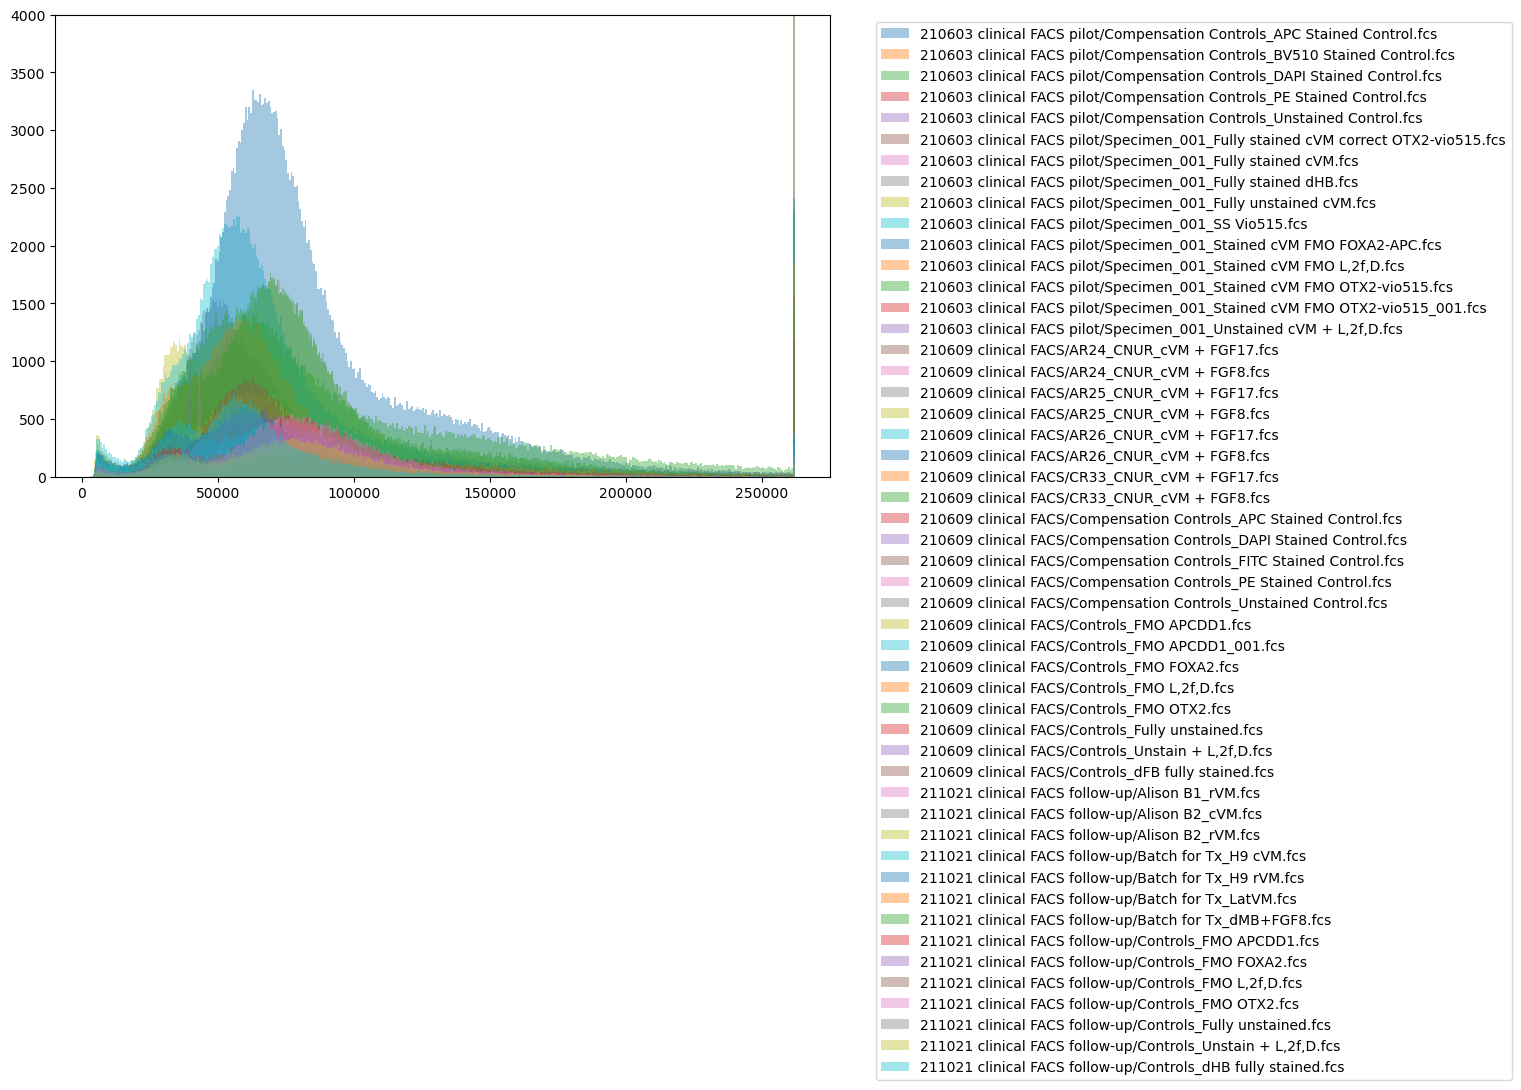

In [7]:
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 4e3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Plot to establish gating 

In [ ]:
#adjust the colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify the colormap
with open("../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]
bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

Skipping fcs_files/210603 clinical FACS pilot/Compensation Controls_APC Stained Control.fcs
Skipping fcs_files/210603 clinical FACS pilot/Compensation Controls_BV510 Stained Control.fcs
Skipping fcs_files/210603 clinical FACS pilot/Compensation Controls_DAPI Stained Control.fcs
Skipping fcs_files/210603 clinical FACS pilot/Compensation Controls_PE Stained Control.fcs
Skipping fcs_files/210603 clinical FACS pilot/Compensation Controls_Unstained Control.fcs
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Fully stained cVM correct OTX2-vio515.fcs


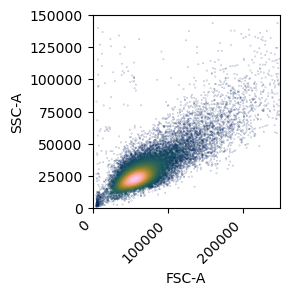

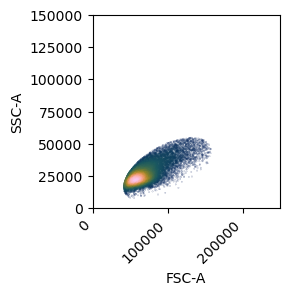

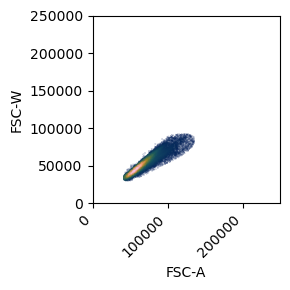

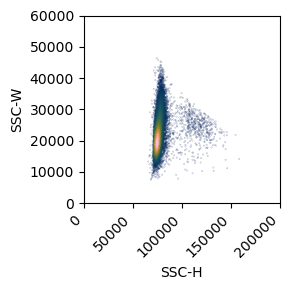

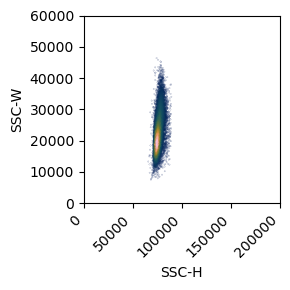

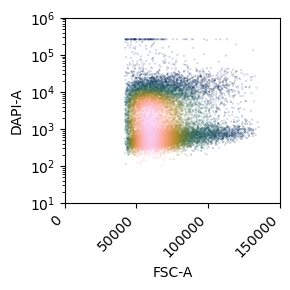

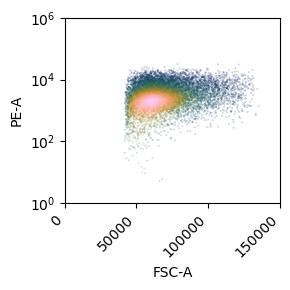

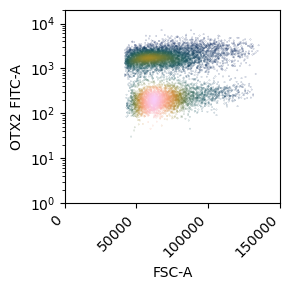

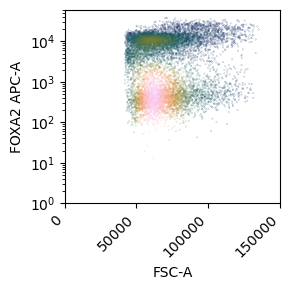

Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Fully stained cVM.fcs


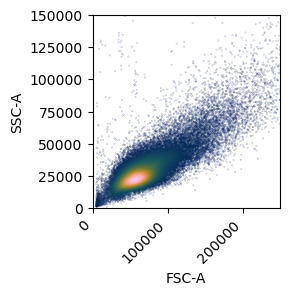

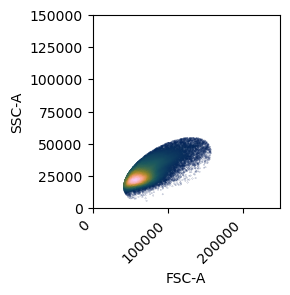

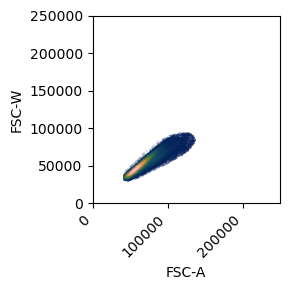

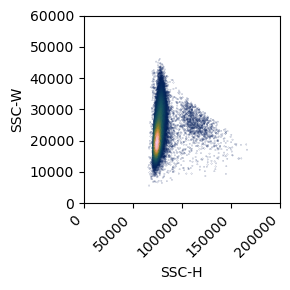

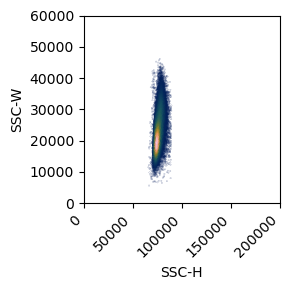

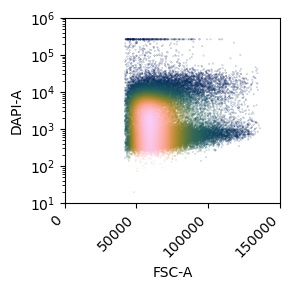

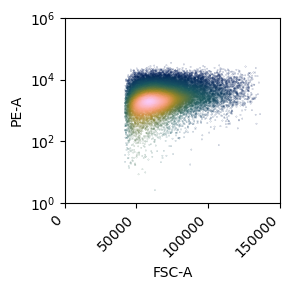

Error processing fcs_files/210603 clinical FACS pilot/Specimen_001_Fully stained cVM.fcs: tuple.index(x): x not in tuple
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Fully stained dHB.fcs


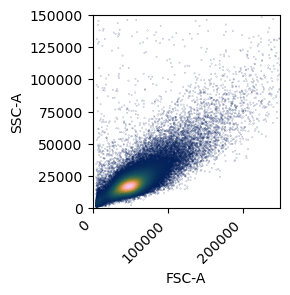

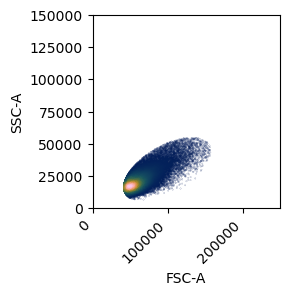

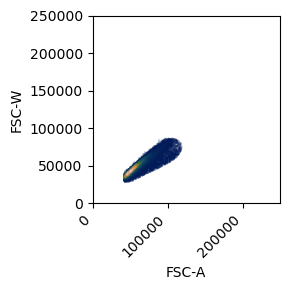

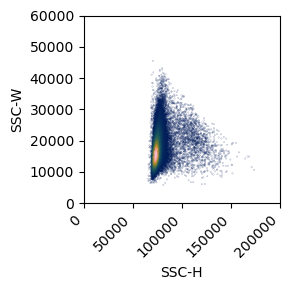

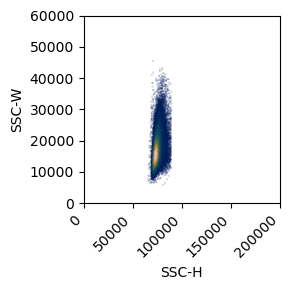

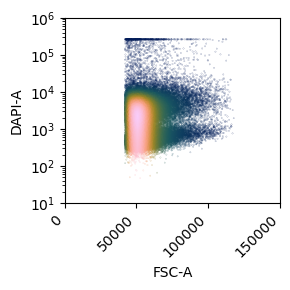

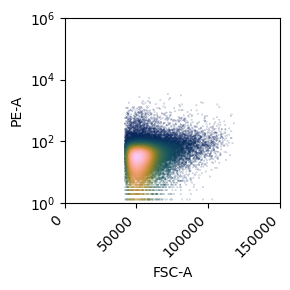

Error processing fcs_files/210603 clinical FACS pilot/Specimen_001_Fully stained dHB.fcs: tuple.index(x): x not in tuple
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Fully unstained cVM.fcs


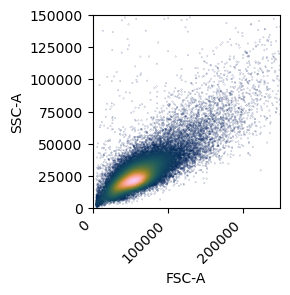

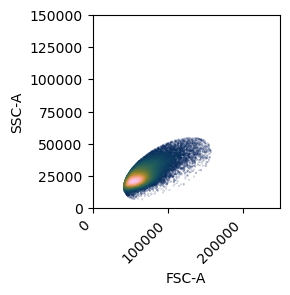

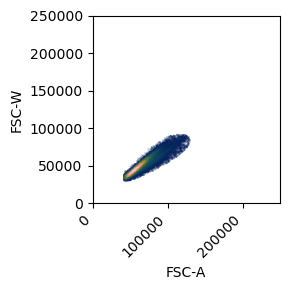

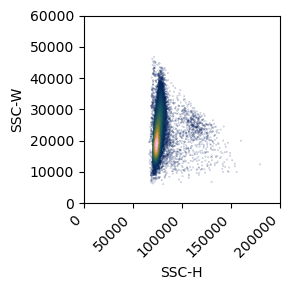

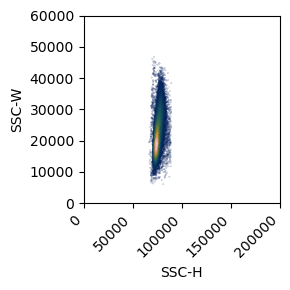

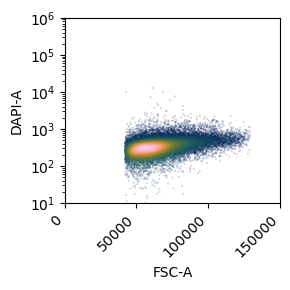

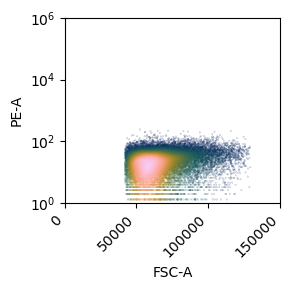

Error processing fcs_files/210603 clinical FACS pilot/Specimen_001_Fully unstained cVM.fcs: tuple.index(x): x not in tuple
Skipping fcs_files/210603 clinical FACS pilot/Specimen_001_SS Vio515.fcs
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Stained cVM FMO FOXA2-APC.fcs


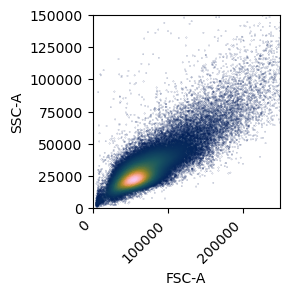

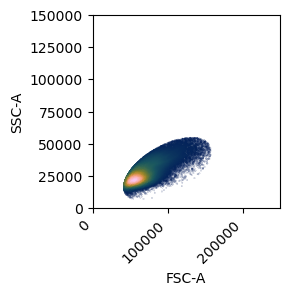

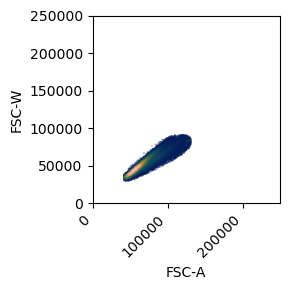

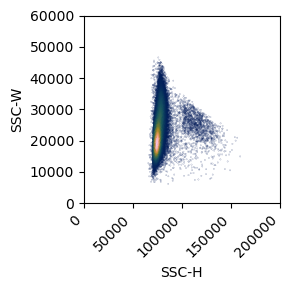

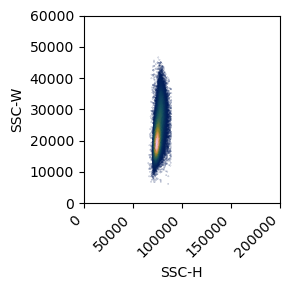

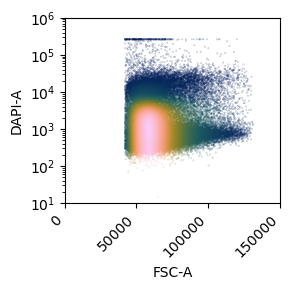

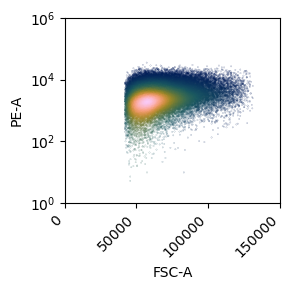

Error processing fcs_files/210603 clinical FACS pilot/Specimen_001_Stained cVM FMO FOXA2-APC.fcs: tuple.index(x): x not in tuple
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Stained cVM FMO L,2f,D.fcs


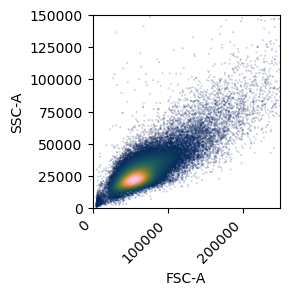

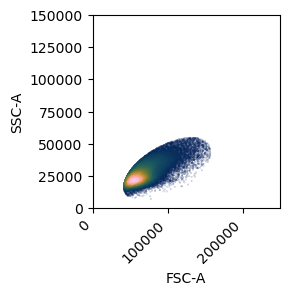

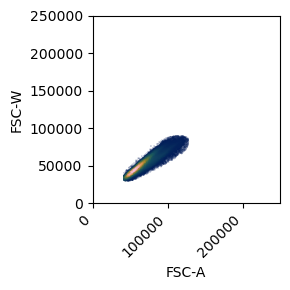

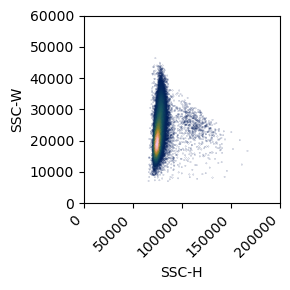

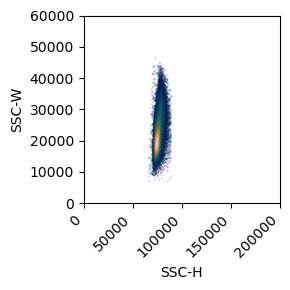

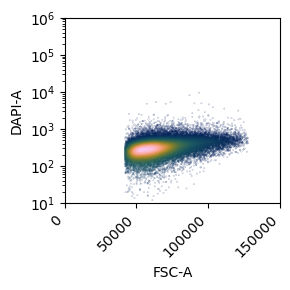

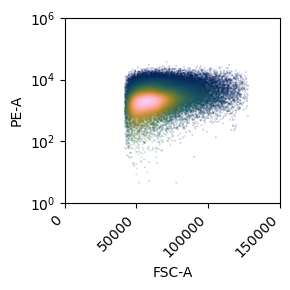

Error processing fcs_files/210603 clinical FACS pilot/Specimen_001_Stained cVM FMO L,2f,D.fcs: tuple.index(x): x not in tuple
Processing file fcs_files/210603 clinical FACS pilot/Specimen_001_Stained cVM FMO OTX2-vio515.fcs


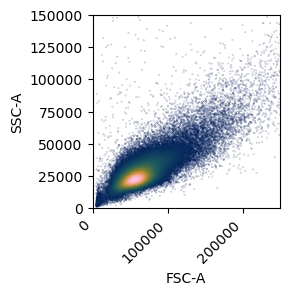

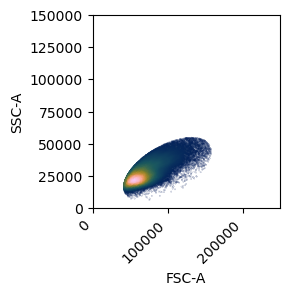

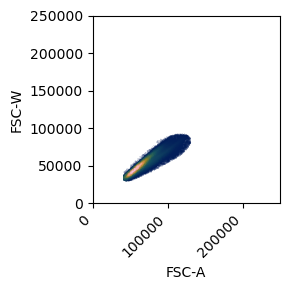

KeyboardInterrupt: 

In [ ]:
def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, yscale='linear', xscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    plt.figure(figsize=(3, 3))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    if xscale == 'log':
        plt.xscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

samples_skip = ['Compensation', 'SS'] #samples to skip

def process_files(imported_files):
    count = 0
    for folder, files in imported_files.items():
        for filename, s in files.items():
            #skip specific samples
            if any(sample in filename for sample in samples_skip):
                print(f"Skipping {filename}")
                continue

            #select specific folder with string 210609
            if '210603' not in filename:
                continue
            
            #select specific samples
            #if 'APCDD1' not in filename:
                #continue

            print(f"Processing file {filename}")
            #print(f"Available channels: {s.channels}")

            count += 1
            if count > 8:
                break


            try:
                if '210609' in filename:
                    plot_density_scatter(s, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 2.5e5), (0, 1.5e5))

                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], 
                                            center=(9.3e4, 3e4), 
                                            a=2e4,
                                            b=6e4, 
                                            theta=-75/180.*np.pi
                                            )
                    plot_density_scatter(g1, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 2.5e5), (0, 1.5e5))
                    plot_density_scatter(g1, 'FSC-A', 'FSC-W', 'FSC-A', 'FSC-W', (0, 2.5e5), (0, 2.5e5))

                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    plot_density_scatter(g2, 'FSC-A', 'FSC-W', 'FSC-A', 'FSC-W', (0, 2.5e5), (0, 2.5e5))
                    plot_density_scatter(g2, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 6e4))

                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], 
                                            center=(7e4, 8e4), 
                                            a=2e4,
                                            b=2e5#,
                                            #theta=-75/180.*np.pi
                                            )
                    plot_density_scatter(g3, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 6e4))
                    plot_density_scatter(g3, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 1.5e5), (1e1, 1e6), yscale='log')

                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                    plot_density_scatter(g4, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 1.5e5), (1e-1, 1e6), yscale='log')
                    
                    #plot the antibody channels
                    #apcdd1-pe
                    plot_density_scatter(g4, 'FSC-A', 'PE-A', 'FSC-A', 'PE-A', (0, 1.5e5), (1, 1e6), yscale='log')

                    #otx2 FITC-A
                    plot_density_scatter(g4, 'FSC-A', 'FITC-A', 'FSC-A', 'OTX2 FITC-A', (0, 1.5e5), (1, 2e4), yscale='log')

                    #foxa2 APC-A
                    plot_density_scatter(g4, 'FSC-A', 'APC-A', 'FSC-A', 'FOXA2 APC-A', (0, 1.5e5), (1, 6e4), yscale='log')

                    #otx2 FITC-A and foxa2 APC-A channels
                    plot_density_scatter(g4, 'FITC-A', 'APC-A', 'OTX2 FITC-A', 'FOXA2 APC-A', (1, 2e4), (1, 6e4), yscale='log', xscale='log')


                else:
                    plot_density_scatter(s, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 2.5e5), (0, 1.5e5))

                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], 
                                            center=(1e5, 3e4), #previous (8e4, 3e4)
                                            a=2e4,
                                            b=6e4, 
                                            theta=-75/180.*np.pi
                                            )
                    plot_density_scatter(g1, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 2.5e5), (0, 1.5e5))

                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    plot_density_scatter(g2, 'FSC-A', 'FSC-W', 'FSC-A', 'FSC-W', (0, 2.5e5), (0, 2.5e5))
                    plot_density_scatter(g2, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 6e4))

                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], 
                                            center=(7e4, 8e4), 
                                            a=2e4,
                                            b=2e5#,
                                            #theta=-75/180.*np.pi
                                            )
                    plot_density_scatter(g3, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 6e4))
                    plot_density_scatter(g3, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 1.5e5), (1e1, 1e6), yscale='log')

                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                    #plot_density_scatter(g4, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 1.5e5), (1e-1, 1e6), yscale='log')
                    
                    #plot the antibody channels
                    #apcdd1-pe
                    plot_density_scatter(g4, 'FSC-A', 'PE-A', 'FSC-A', 'PE-A', (0, 1.5e5), (1, 1e6), yscale='log')

                    #otx2 FITC-A
                    plot_density_scatter(g4, 'FSC-A', 'FITC-A', 'FSC-A', 'OTX2 FITC-A', (0, 1.5e5), (1, 2e4), yscale='log')

                    #foxa2 APC-A
                    plot_density_scatter(g4, 'FSC-A', 'APC-A', 'FSC-A', 'FOXA2 APC-A', (0, 1.5e5), (1, 6e4), yscale='log')

            except ValueError as e:
                print(f"Error processing {filename}: {e}")


#make a dictionary (with the folders as keys and the fcs files as value)
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files)

## Calculate cutoffs

In [10]:
#remove the 210603 clinical FACS pilot folder from the imported_files dictionary save as new dictionary
imported_files_210609_211021 = {}
for folder, files in imported_files.items():
    if folder == '210609 clinical FACS' or folder == '211021 clinical FACS follow-up':
        imported_files_210609_211021[folder] = files

#check all filenames in the imported_files dictionary
for folder, files in imported_files_210609_211021.items():
    print(f"Folder: {folder}")
    for filename in files.keys():
        print(f"  Filename: {filename}")

Folder: 210609 clinical FACS
  Filename: fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
  Filename: fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
  Filename: fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
  Filename: fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
  Filename: fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
  Filename: fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF8.fcs
  Filename: fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF17.fcs
  Filename: fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF8.fcs
  Filename: fcs_files/210609 clinical FACS/Compensation Controls_APC Stained Control.fcs
  Filename: fcs_files/210609 clinical FACS/Compensation Controls_DAPI Stained Control.fcs
  Filename: fcs_files/210609 clinical FACS/Compensation Controls_FITC Stained Control.fcs
  Filename: fcs_files/210609 clinical FACS/Compensation Controls_PE Stained Control.fcs
  Filename: fcs_files/210609 clinical FACS/Compensation Controls_U

### Cutoffs based on FMOs

#### Calculate cutoffs

In [ ]:
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {folder: {'PE': [], 'FITC': [], 'APC' : []} for folder in imported_files.keys()}

fmos=['FMO APCDD1', 'FMO FOXA2', 'FMO OTX2']

for folder, files in imported_files.items():
    for filename, s in files.items():
        #only include fmos
        if any(sample in filename for sample in fmos):
            #exclude the 210603 pilot experiment
            if '210603' in filename:
                continue 
            #print(f"Include file {filename} - it's an FMO.")
            #print(f"Available channels in {filename}: {s.channels}")
            #processing for files meeting the second condition
            try:
                if '210609' in filename:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4,b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                else:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1e5, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

                #pe
                if 'PE-A' in g4.channels:
                    if 'APCDD1' in filename:
                        if len(g4[:, 'PE-A']) > 0:
                            fmo_percentiles[folder]['PE'].append(np.percentile(g4[:, 'PE-A'], 99.8))
                        else:
                            fmo_percentiles[folder]['PE'].append(np.nan)
                    else:
                        print(f"No APCDD1 in {filename}")
                else:
                    fmo_percentiles[folder]['PE'].append(np.nan)
                    print(f"No PE-A channel in {filename}")

                #fitc
                if 'FITC-A' in g4.channels:
                    if 'OTX2' in filename:
                        if len(g4[:, 'FITC-A']) > 0:
                            fmo_percentiles[folder]['FITC'].append(np.percentile(g4[:, 'FITC-A'], 99.8))
                        else:
                            fmo_percentiles[folder]['FITC'].append(np.nan)
                    else:
                        print(f"No OTX2 in {filename}")
                else:
                    fmo_percentiles[folder]['FITC'].append(np.nan)
                    print(f"No FITC-A channel in {filename}")

                #apc
                if 'APC-A' in g4.channels:
                    if 'FOXA2' in filename:
                        if len(g4[:, 'APC-A']) > 0:
                            fmo_percentiles[folder]['APC'].append(np.percentile(g4[:, 'APC-A'], 99.8))
                        else:
                            fmo_percentiles[folder]['APC'].append(np.nan)
                    else:
                        print(f"No FOXA2 in {filename}")
                else:
                    fmo_percentiles[folder]['APC'].append(np.nan)
                    print(f"No APC-A channel in {filename}")

            except ValueError as e:
                print(f"Error processing {filename}: {e}")

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {folder: {k: np.mean(v) for k, v in fmo_percentiles[folder].items()} for folder in imported_files.keys()}
perc_cutoffs

No OTX2 in fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
No FOXA2 in fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
No OTX2 in fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
No FOXA2 in fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
No APCDD1 in fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
No OTX2 in fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
No APCDD1 in fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
No FOXA2 in fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
No OTX2 in fcs_files/211021 clinical FACS follow-up/Controls_FMO APCDD1.fcs
No FOXA2 in fcs_files/211021 clinical FACS follow-up/Controls_FMO APCDD1.fcs
No APCDD1 in fcs_files/211021 clinical FACS follow-up/Controls_FMO FOXA2.fcs
No OTX2 in fcs_files/211021 clinical FACS follow-up/Controls_FMO FOXA2.fcs
No APCDD1 in fcs_files/211021 clinical FACS follow-up/Controls_FMO OTX2.fcs
No FOXA2 in fcs_files/211021 clinical FACS follow-up/Controls_FMO OTX2.fcs


/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


{'210603 clinical FACS pilot': {'PE': nan, 'FITC': nan, 'APC': nan},
 '210609 clinical FACS': {'PE': 112.92969619750994,
  'FITC': 347.3012524414014,
  'APC': 171.8199920654297},
 '211021 clinical FACS follow-up': {'PE': 117.25,
  'FITC': 386.235190368661,
  'APC': 141.09971353149155}}

#### Plot to show %+

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 112.92969619750994
Number of events: 33138
Number of gated events: 30795


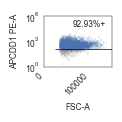

Cutoff for FITC in folder 210609 clinical FACS: 347.3012524414014
Number of events: 33138
Number of gated events: 17534


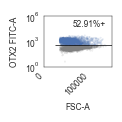

Cutoff for APC in folder 210609 clinical FACS: 171.8199920654297
Number of events: 33138
Number of gated events: 31062


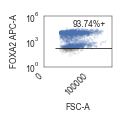

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 112.92969619750994
Number of events: 36693
Number of gated events: 28445


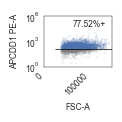

Cutoff for FITC in folder 210609 clinical FACS: 347.3012524414014
Number of events: 36693
Number of gated events: 14755


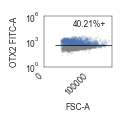

Cutoff for APC in folder 210609 clinical FACS: 171.8199920654297
Number of events: 36693
Number of gated events: 34620


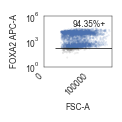

Processing file fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 112.92969619750994
Number of events: 34279
Number of gated events: 34065


KeyboardInterrupt: 

In [ ]:
custom_theme_6pt()

def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, yscale='linear', xscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = plt.cm.viridis(norm(z))

    plt.figure(figsize=(3, 3))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    if xscale == 'log':
        plt.xscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#samples to skip
samples_skip = ['Compensation', 'SS'] #compensation and single-stained controls

def process_files(imported_files, perc_cutoffs):
    count = 0
    for folder, files in imported_files.items():
        for filename, s in files.items():

            #skip specific samples
            if any(sample in filename for sample in samples_skip): #exclude SS and compensation controls
                continue
            if '210603' in filename: #exclude the 210603 pilot
                continue

            print(f"Processing file {filename}")
            print(f"Available channels: {s.channels}")

            count += 1
            if count > 4:
                break

            try:
                if '210609' in filename:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                else:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1e5, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

                fluorophore = 'PE'
                fluorophore_channel = 'PE-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                #retrieve gating cutoff
                cutoff = perc_cutoffs[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in perc_cutoffs[{folder}]: {perc_cutoffs[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('PE-A')].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                #sample 4000 events
                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                #calculate the percentage of events that are gated
                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                #add horizontal lines
                line_start = 0.25e5 
                line_end = 1.8e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                #add text (with %gated)
                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('APCDD1 PE-A')
                plt.xlim(0, 1.5e5)
                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated pe.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated pe.pdf", dpi=150)
                plt.show()

                #OTX2 FITC-A
                fluorophore = 'FITC'
                fluorophore_channel = 'FITC-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                #retrieve cutoffs
                cutoff = perc_cutoffs[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in perc_cutoffs[{folder}]: {perc_cutoffs[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('FITC-A')].astype('<f8')

                #calculate density
                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                #sample 4000 events
                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                #calculate %gated events
                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                #add horizontal lines
                line_start = 0.25e5
                line_end = 1.8e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                #add text (with %gated)
                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('OTX2 FITC-A')
                plt.xlim(0, 1.5e5)
                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated fitc.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated fitc.pdf", dpi=150)
                plt.show()

                #FOXA2 APC-A
                fluorophore = 'APC'
                fluorophore_channel = 'APC-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                #retrieve gating cutoff
                cutoff = perc_cutoffs[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in perc_cutoffs[{folder}]: {perc_cutoffs[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('APC-A')].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                #calculate the percentage of events that are gated
                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                #add horizontal lines
                line_start = 0.25e5
                line_end = 1.8e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                # Add text to the plot
                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('FOXA2 APC-A')
                plt.xlim(0, 1.5e5)
                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated apc.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated apc.pdf", dpi=150)
                plt.show()

            except ValueError as e:
                print(f"Error processing {filename}: {e}")

#make a dictionary (with the folders as keys and the fcs files as value)
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files, perc_cutoffs)

### Cutoffs based on biological control

#### Calculate cutoffs

In [ ]:
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#calculate relevant metrics
ctrl_percentiles = {folder: {'PE': [], 'FITC': [], 'APC': []} for folder in imported_files.keys()}
ctrl_means = {folder: {'PE': [], 'FITC': [], 'APC': []} for folder in imported_files.keys()}
ctrl_stds = {folder: {'PE': [], 'FITC': [], 'APC': []} for folder in imported_files.keys()}

neg_ctrls = ['dFB', 'dHB', 'FMO APCDD1', 'FMO OTX2']

for folder, files in imported_files.items():
    for filename, s in files.items():
        #only include negative controls
        if any(sample in filename for sample in neg_ctrls):
            #exclude the 210603 pilot experiment
            if '210603' in filename:
                continue
            print(f"Include file {filename} - it's a control.")
            print(f"Available channels in {filename}: {s.channels}")
            #processing for files
            try:
                if '210609' in filename:
                    if 'dFB' in filename or 'APCDD1' in filename or 'OTX2' in filename:
                        g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                        g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                        g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                else:
                    if 'dHB' in filename:
                        g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1e5, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                        g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                        g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

                #pe
                if 'PE-A' in g4.channels:
                    if 'APCDD1' in filename:
                        if len(g4[:, 'PE-A']) > 0:
                            ctrl_percentiles[folder]['PE'].append(np.percentile(g4[:, 'PE-A'], 99.8))
                            ctrl_means[folder]['PE'].append(np.mean(g4[:, 'PE-A']))
                            ctrl_stds[folder]['PE'].append(np.std(g4[:, 'PE-A']))

                        else:
                            ctrl_percentiles[folder]['PE'].append(np.nan)
                            ctrl_means[folder]['PE'].append(np.nan)
                            ctrl_stds[folder]['PE'].append(np.nan)
                    else:
                        print(f"No APCDD1 in {filename}")
                else:
                    ctrl_percentiles[folder]['PE'].append(np.nan)
                    ctrl_means[folder]['PE'].append(np.nan)
                    ctrl_stds[folder]['PE'].append(np.nan)
                    print(f"No PE-A channel in {filename}")

                #fitc
                if 'FITC-A' in g4.channels:
                    if 'OTX2' in filename and '210609' in filename:
                        if len(g4[:, 'FITC-A']) > 0:
                            ctrl_percentiles[folder]['FITC'].append(np.percentile(g4[:, 'FITC-A'], 99.8))
                            ctrl_means[folder]['FITC'].append(np.mean(g4[:, 'FITC-A']))
                            ctrl_stds[folder]['FITC'].append(np.std(g4[:, 'FITC-A']))
                        else:
                            ctrl_percentiles[folder]['FITC'].append(np.nan)
                            ctrl_means[folder]['FITC'].append(np.nan)
                            ctrl_stds[folder]['FITC'].append(np.nan)
                    elif 'dHB' in filename and '211021' in filename:
                        if len(g4[:, 'FITC-A']) > 0:
                            ctrl_percentiles[folder]['FITC'].append(np.percentile(g4[:, 'FITC-A'], 99.8))
                            ctrl_means[folder]['FITC'].append(np.mean(g4[:, 'FITC-A']))
                            ctrl_stds[folder]['FITC'].append(np.std(g4[:, 'FITC-A']))
                        else:
                            ctrl_percentiles[folder]['FITC'].append(np.nan)
                            ctrl_means[folder]['FITC'].append(np.nan)
                            ctrl_stds[folder]['FITC'].append(np.nan)
                    else:
                        print(f"No OTX2 or dHB in {filename}")
                else:
                    ctrl_percentiles[folder]['FITC'].append(np.nan)
                    ctrl_means[folder]['FITC'].append(np.nan)
                    ctrl_stds[folder]['FITC'].append(np.nan)
                    print(f"No FITC-A channel in {filename}")

                #apc
                if 'APC-A' in g4.channels:
                    if 'dFB' in filename or 'dHB' in filename:
                        if len(g4[:, 'APC-A']) > 0:
                            ctrl_percentiles[folder]['APC'].append(np.percentile(g4[:, 'APC-A'], 99.8))
                            ctrl_means[folder]['APC'].append(np.mean(g4[:, 'APC-A']))
                            ctrl_stds[folder]['APC'].append(np.std(g4[:, 'APC-A']))
                        else:
                            ctrl_percentiles[folder]['APC'].append(np.nan)
                            ctrl_means[folder]['APC'].append(np.nan)
                            ctrl_stds[folder]['APC'].append(np.nan)
                    else:
                        print(f"No dFB or dHB in {filename}")
                else:
                    ctrl_percentiles[folder]['APC'].append(np.nan)
                    ctrl_means[folder]['APC'].append(np.nan)
                    ctrl_stds[folder]['APC'].append(np.nan)
                    print(f"No APC-A channel in {filename}")

            except ValueError as e:
                print(f"Error processing {filename}: {e}")

#retrieve relevant metrics
ctrl_perc_cutoffs = {folder: {k: np.nanmean(v) for k, v in ctrl_percentiles[folder].items()} for folder in imported_files.keys()}
print(f"99.8th percentile: {ctrl_perc_cutoffs}")

mean_of_means = {folder: {k: np.mean(v) for k, v in ctrl_means[folder].items()} for folder in imported_files.keys()}
mean_of_stds = {folder: {k: np.mean(v) for k, v in ctrl_stds[folder].items()} for folder in imported_files.keys()}

#calculate the mean+sd cutoffs
#3 sd
std_cutoffs_3 = {folder: {k: mean + 6*std for k, mean, std in zip(mean_of_means[folder].keys(), 
                                                                  mean_of_means[folder].values(), 
                                                                  mean_of_stds[folder].values())} for folder in imported_files.keys()} 

print(f"Mean+3std cutoffs: {std_cutoffs_3}")

#changed to 8 sd
std_cutoffs_10 = {folder: {k: mean + 8*std for k, mean, std in zip(mean_of_means[folder].keys(), 
                                                                  mean_of_means[folder].values(), 
                                                                  mean_of_stds[folder].values())} for folder in imported_files.keys()} 

print(f"Means+10std cutoffs: {std_cutoffs_10}")

#create a new dictionary that combines the 3 and 10 SDs cutoffs
std_cutoffs_mix = {}

for folder in std_cutoffs_10:
    std_cutoffs_mix[folder] = {}
    for fluor in std_cutoffs_10[folder]:
        if fluor == "PE":
            std_cutoffs_mix[folder][fluor] = std_cutoffs_10[folder][fluor]
        else:
            std_cutoffs_mix[folder][fluor] = std_cutoffs_3[folder][fluor]

#print the calculated cutoffs
print(f"Mixed mean+std cutoffs: {std_cutoffs_mix}")

Include file fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs - it's a control.
Available channels in fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
No OTX2 or dHB in fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
No dFB or dHB in fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
Include file fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs - it's a control.
Available channels in fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
No OTX2 or dHB in fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
No dFB or dHB in fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
Include file fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs - it's a control.
Available channels in fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs: ('Time

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_42729/939404365.py:113: RuntimeWarning: Mean of empty slice
  ctrl_perc_cutoffs = {folder: {k: np.nanmean(v) for k, v in ctrl_percentiles[folder].items()} for folder in imported_files.keys()}


#### Plot %+

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 33138
Number of gated events: 23969


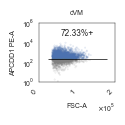

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Number of events: 33138
Number of gated events: 16969


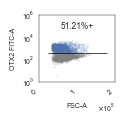

Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 33138
Number of gated events: 23481


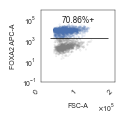

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 36693
Number of gated events: 15043


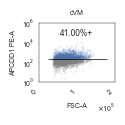

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Number of events: 36693
Number of gated events: 13465


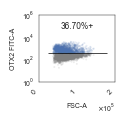

Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 36693
Number of gated events: 22014


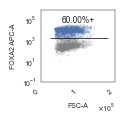

Processing file fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 34279
Number of gated events: 33757


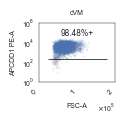

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Number of events: 34279
Number of gated events: 28583


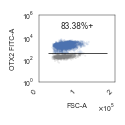

Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 34279
Number of gated events: 31775


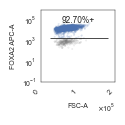

Processing file fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 34408
Number of gated events: 31841


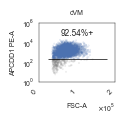

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Number of events: 34408
Number of gated events: 28721


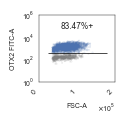

Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 34408
Number of gated events: 32976


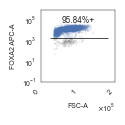

Processing file fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Processing file fcs_files/211021 clinical FACS follow-up/Alison B1_rVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')


In [ ]:
custom_theme_5pt()

def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, yscale='linear', xscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = plt.cm.viridis(norm(z))

    plt.figure(figsize=(3, 3))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    if xscale == 'log':
        plt.xscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#samples to skip
samples_skip = ['Compensation', 'SS']

def process_files(imported_files, cutoff_dict):
    count = 0
    for folder, files in imported_files.items():
        for filename, s in files.items():

            #skip specific samples
            if any(sample in filename for sample in samples_skip):
                continue
            if '210603' in filename:
                continue

            print(f"Processing file {filename}")
            print(f"Available channels: {s.channels}")

            count += 1
            if count > 4:
                break

            try:
                if '210609' in filename:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                else:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1e5, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

                fluorophore = 'PE'
                fluorophore_channel = 'PE-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                cutoff = cutoff_dict[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in cutoff_dict[{folder}]: {cutoff_dict[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('PE-A')].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                line_start = 0.25e5
                line_end = 1.8e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('APCDD1 PE-A')
                if 'cVM' in filename:
                    plt.title('cVM')
                elif 'dFB' in filename:
                    plt.title('dFB')
                elif 'dHB' in filename:
                    plt.title('dHB')
                else:
                    plt.title('Unknown Sample')

                ax = plt.gca()
                ax.set_xticks([1e-1, 1e5, 2e5])
                formatter = ticker.ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((0, 0))
                ax.xaxis.set_major_formatter(formatter)
                plt.xticks(rotation=45, ha='center')

                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated pe.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated pe.pdf", dpi=150)
                plt.show()

                #OTX2 FITC-A
                fluorophore = 'FITC'
                fluorophore_channel = 'FITC-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                #retrieve gating cutoff
                cutoff = cutoff_dict[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in cutoff_dict[{folder}]: {cutoff_dict[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                #apply gating and calculate the mean of gated data
                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('FITC-A')].astype('<f8')

                #calculate density
                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                line_start = 0.25e5  # Starting x-coordinate for the horizontal line
                line_end = 1.8e5    # Ending x-coordinate for the horizontal line
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('OTX2 FITC-A')

                ax = plt.gca()
                ax.set_xticks([0, 1e5, 2e5])
                formatter = ticker.ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((0, 0))
                ax.xaxis.set_major_formatter(formatter)
                plt.xticks(rotation=45, ha='center')

                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated fitc.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated fitc.pdf", dpi=150)
                plt.show()

                #FOXA2 APC-A
                fluorophore = 'APC'
                fluorophore_channel = 'APC-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

                #retrieve gating cutoff
                cutoff = cutoff_dict[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in cutoff_dict[{folder}]: {cutoff_dict[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                #apply gating and calculate the mean of gated data
                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of gated events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('APC-A')].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.1, alpha=0.2)

                line_start = 0.25e5
                line_end = 1.8e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                plt.text(1e5, 1e5, f"{gated_percentage:.2f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'))

                plt.xlabel('FSC-A')
                plt.ylabel('FOXA2 APC-A')

                ax = plt.gca()
                ax.set_xticks([0, 1e5, 2e5])
                formatter = ticker.ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((0, 0))
                ax.xaxis.set_major_formatter(formatter)
                plt.xticks(rotation=45, ha='center')

                plt.ylim(1e-1, 1e6)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated apc.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated apc.pdf", dpi=150)
                plt.show()

            except ValueError as e:
                print(f"Error processing {filename}: {e}")

#make a dictionary (with the folders as keys and the fcs files as value)
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files, std_cutoffs_mix)

#### Plot %+ - FITC and APC in same

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 33138
Number of PE+ events: 23969


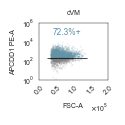

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 33138
Number of FITC+ events: 16969
Number of APC+ events: 23481
Number of FITC+APC+ events: 16809


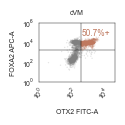

Processing file fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 36693
Number of PE+ events: 15043


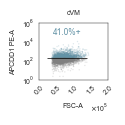

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 36693
Number of FITC+ events: 13465
Number of APC+ events: 22014
Number of FITC+APC+ events: 13137


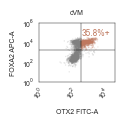

Processing file fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 34279
Number of PE+ events: 33757


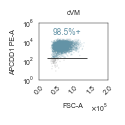

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 34279
Number of FITC+ events: 28583
Number of APC+ events: 31775
Number of FITC+APC+ events: 28521


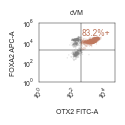

Processing file fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 34408
Number of PE+ events: 31841


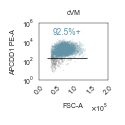

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 34408
Number of FITC+ events: 28721
Number of APC+ events: 32976
Number of FITC+APC+ events: 28625


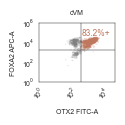

Processing file fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 35961
Number of PE+ events: 34548


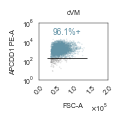

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 35961
Number of FITC+ events: 31445
Number of APC+ events: 33425
Number of FITC+APC+ events: 31311


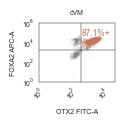

Processing file fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 45803
Number of PE+ events: 36880


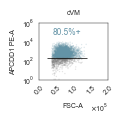

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 45803
Number of FITC+ events: 38855
Number of APC+ events: 42531
Number of FITC+APC+ events: 38545


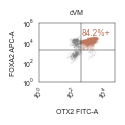

Processing file fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF17.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 31520
Number of PE+ events: 29339


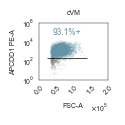

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 31520
Number of FITC+ events: 26253
Number of APC+ events: 30659
Number of FITC+APC+ events: 26193


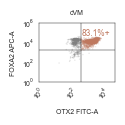

Processing file fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 35695
Number of PE+ events: 30848


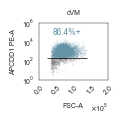

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 35695
Number of FITC+ events: 27222
Number of APC+ events: 33899
Number of FITC+APC+ events: 27100


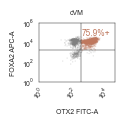

Processing file fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 41029
Number of PE+ events: 5


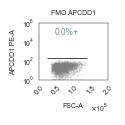

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 41029
Number of FITC+ events: 33545
Number of APC+ events: 37253
Number of FITC+APC+ events: 33401


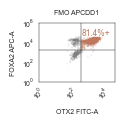

Processing file fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 10755
Number of PE+ events: 3


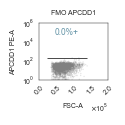

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 10755
Number of FITC+ events: 8747
Number of APC+ events: 9769
Number of FITC+APC+ events: 8691


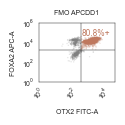

Processing file fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 34149
Number of PE+ events: 14597


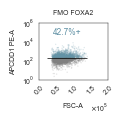

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 34149
Number of FITC+ events: 10498
Number of APC+ events: 0
Number of FITC+APC+ events: 0


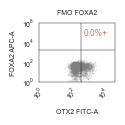

Processing file fcs_files/210609 clinical FACS/Controls_FMO L,2f,D.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 33708
Number of PE+ events: 13969


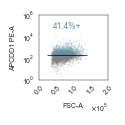

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 33708
Number of FITC+ events: 12121
Number of APC+ events: 20609
Number of FITC+APC+ events: 11872


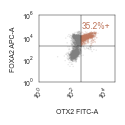

Processing file fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 43632
Number of PE+ events: 16510


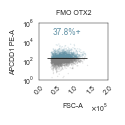

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 43632
Number of FITC+ events: 48
Number of APC+ events: 29846
Number of FITC+APC+ events: 31


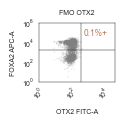

Processing file fcs_files/210609 clinical FACS/Controls_Fully unstained.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 33654
Number of PE+ events: 6


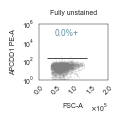

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 33654
Number of FITC+ events: 36
Number of APC+ events: 4
Number of FITC+APC+ events: 0


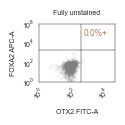

Processing file fcs_files/210609 clinical FACS/Controls_Unstain + L,2f,D.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 33687
Number of PE+ events: 3


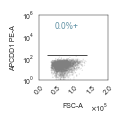

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 33687
Number of FITC+ events: 25
Number of APC+ events: 2
Number of FITC+APC+ events: 0


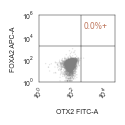

Processing file fcs_files/210609 clinical FACS/Controls_dFB fully stained.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 210609 clinical FACS: 228.18966102600098
Number of events: 29230
Number of PE+ events: 150


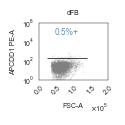

Cutoff for FITC in folder 210609 clinical FACS: 393.9222183227539
Cutoff for APC in folder 210609 clinical FACS: 1842.642822265625
Number of events: 29230
Number of FITC+ events: 24790
Number of APC+ events: 18
Number of FITC+APC+ events: 11


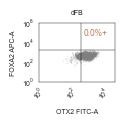

Processing file fcs_files/211021 clinical FACS follow-up/Alison B1_rVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 27672
Number of PE+ events: 17912


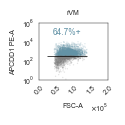

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 27672
Number of FITC+ events: 3075
Number of APC+ events: 21215
Number of FITC+APC+ events: 2358


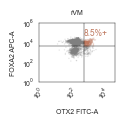

Processing file fcs_files/211021 clinical FACS follow-up/Alison B2_cVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 19152
Number of PE+ events: 16726


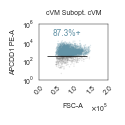

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 19152
Number of FITC+ events: 6421
Number of APC+ events: 14352
Number of FITC+APC+ events: 6082


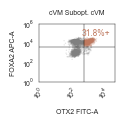

Processing file fcs_files/211021 clinical FACS follow-up/Alison B2_rVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 18121
Number of PE+ events: 11461


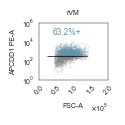

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 18121
Number of FITC+ events: 1799
Number of APC+ events: 14143
Number of FITC+APC+ events: 1353


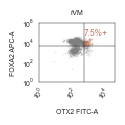

Processing file fcs_files/211021 clinical FACS follow-up/Batch for Tx_H9 cVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 29565
Number of PE+ events: 10631


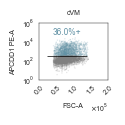

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 29565
Number of FITC+ events: 4773
Number of APC+ events: 8069
Number of FITC+APC+ events: 3243


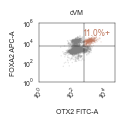

Processing file fcs_files/211021 clinical FACS follow-up/Batch for Tx_H9 rVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 29404
Number of PE+ events: 21021


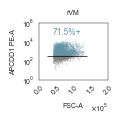

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 29404
Number of FITC+ events: 7880
Number of APC+ events: 22572
Number of FITC+APC+ events: 6964


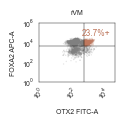

Processing file fcs_files/211021 clinical FACS follow-up/Batch for Tx_LatVM.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 9044
Number of PE+ events: 8257


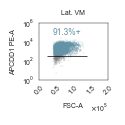

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 9044
Number of FITC+ events: 5639
Number of APC+ events: 8348
Number of FITC+APC+ events: 5391


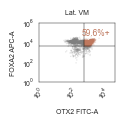

Processing file fcs_files/211021 clinical FACS follow-up/Batch for Tx_dMB+FGF8.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 9903
Number of PE+ events: 2614


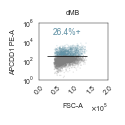

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 9903
Number of FITC+ events: 2174
Number of APC+ events: 163
Number of FITC+APC+ events: 160


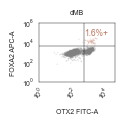

Processing file fcs_files/211021 clinical FACS follow-up/Controls_FMO APCDD1.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 29630
Number of PE+ events: 0


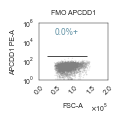

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 29630
Number of FITC+ events: 12628
Number of APC+ events: 25780
Number of FITC+APC+ events: 12014


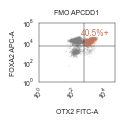

Processing file fcs_files/211021 clinical FACS follow-up/Controls_FMO FOXA2.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 19568
Number of PE+ events: 16934


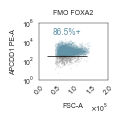

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 19568
Number of FITC+ events: 7595
Number of APC+ events: 0
Number of FITC+APC+ events: 0


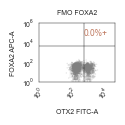

Processing file fcs_files/211021 clinical FACS follow-up/Controls_FMO L,2f,D.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 8946
Number of PE+ events: 7887


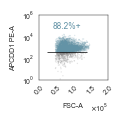

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 8946
Number of FITC+ events: 3356
Number of APC+ events: 7475
Number of FITC+APC+ events: 3225


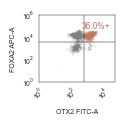

Processing file fcs_files/211021 clinical FACS follow-up/Controls_FMO OTX2.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 29238
Number of PE+ events: 25427


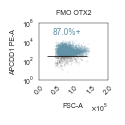

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 29238
Number of FITC+ events: 5
Number of APC+ events: 23369
Number of FITC+APC+ events: 4


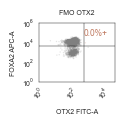

Processing file fcs_files/211021 clinical FACS follow-up/Controls_Fully unstained.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 16411
Number of PE+ events: 1


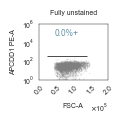

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 16411
Number of FITC+ events: 5
Number of APC+ events: 0
Number of FITC+APC+ events: 0


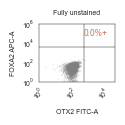

Processing file fcs_files/211021 clinical FACS follow-up/Controls_Unstain + L,2f,D.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 20152
Number of PE+ events: 0


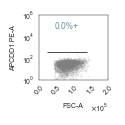

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 20152
Number of FITC+ events: 7
Number of APC+ events: 0
Number of FITC+APC+ events: 0


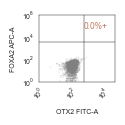

Processing file fcs_files/211021 clinical FACS follow-up/Controls_dHB fully stained.fcs
Available channels: ('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'APC-A', 'DAPI-A', 'PE-A', 'FITC-A')
Cutoff for PE in folder 211021 clinical FACS follow-up: 392.37575340270996
Number of events: 28990
Number of PE+ events: 759


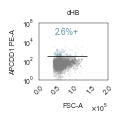

Cutoff for FITC in folder 211021 clinical FACS follow-up: 613.5405502319336
Cutoff for APC in folder 211021 clinical FACS follow-up: 4583.18115234375
Number of events: 28990
Number of FITC+ events: 114
Number of APC+ events: 16
Number of FITC+APC+ events: 3


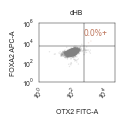

In [ ]:
import matplotlib.ticker as ticker

custom_theme_5pt()

def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, x_cutoff=None, y_cutoff=None, yscale='linear', xscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = plt.cm.viridis(norm(z))

    plt.figure(figsize=(3, 3))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    if xscale == 'log':
        plt.xscale('log')
    if x_cutoff is not None:
        plt.axvline(x=x_cutoff, color='black', linestyle='-', linewidth=0.5, label=f"X Cutoff: {x_cutoff:.2f}")
    if y_cutoff is not None:
        plt.axhline(y=y_cutoff, color='black', linestyle='-', linewidth=0.5, label=f"Y Cutoff: {y_cutoff:.2f}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#samples to skip
samples_skip = ['Compensation', 'SS']

strings_keep=['dFB', 'dHB', 'cVM', 
              
              'Fully stained', #'fully stained',
              'Fully unstained',
              

              'FMO APCDD1', 'FMO OTX2', 'FMO FOXA2',
              #'FGF8', 'FGF17',
              'rVM', 'Tx_LatVM', 'B2_cVM','dMB+FGF8'
              ]

def process_files(imported_files, ctrl_perc_cutoffs):
    #count = 0
    for folder, files in imported_files.items():
        for filename, s in files.items():
            
            #extract and clean the title
            title_parts = [string for string in strings_keep if string in filename]
            title = ' '.join(title_parts)

            #replace string 'B2_cVM' in filename with 'Subopt. cVM'
            title = title.replace('B2_cVM', 'Subopt. cVM')
            title = title.replace('Tx_LatVM', 'Lat. VM')
            title = title.replace('dMB+FGF8', 'dMB')

            #skip specific samples
            if any(sample in filename for sample in samples_skip): # Exclude SS and compensation controls
                continue
            if '210603' in filename:
                continue

            print(f"Processing file {filename}")
            print(f"Available channels: {s.channels}")

            #count += 1
            #if count > 2:
                #break

            try:
                if '210609' in filename:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
                else:
                    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1e5, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                    g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'], center=(7e4, 8e4), a=2e4, b=2e5)
                    g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

                #plot for pe
                fluorophore = 'PE'
                fluorophore_channel = 'PE-A'
                fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')
                
                #retrieve gating cutoff
                cutoff = ctrl_perc_cutoffs[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    print(f"Available keys in ctrl_perc_cutoffs[{folder}]: {ctrl_perc_cutoffs[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore} in folder {folder}: {cutoff}")

                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                print(f"Number of events: {len(fluorophore_data)}")
                print(f"Number of PE+ events: {len(gated_data)}")

                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = g4[:, g4.channels.index('PE-A')].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                #norm = Normalize(vmin=z.min(), vmax=z.max())
                colors = np.where(scatter_y >= cutoff, 
                                  '#6393A6',# '#4C72B0', 
                                  'gray'
                                  )

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                gated_percentage = len(gated_data) / g4.shape[0] * 100

                

                #plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=1, alpha=0.2,linewidths=0)

                line_start = 0.25e5
                line_end = 1.4e5
                plt.hlines(y=cutoff, xmin=line_start, xmax=line_end, colors='black', linestyles='-', label=f"Cutoff: {cutoff:.2f}", linewidth=0.5)

                plt.text(8.2e4, 1e5, f"{gated_percentage:.1f}%+", fontsize=6, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none'), 
                         color='#6393A6' #'#4C72B0'
                         )
                plt.title(title)
                plt.xlabel('FSC-A')
                plt.ylabel('APCDD1 PE-A')
                plt.xlim(0, 2e5)
                plt.ylim(1, 1e6)
                plt.yscale('log')

                ax = plt.gca()
                ax.set_xticks([0, 0.5e5, 1e5, 1.5e5, 2e5])
                formatter = ticker.ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((0, 0))
                ax.xaxis.set_major_formatter(formatter)
                plt.xticks(rotation=45, ha='center')
                ax.xaxis.set_tick_params(pad=2)

                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated pe.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated pe.pdf", dpi=150)
                plt.show()

                #plot fitc and apc in same graph
                fluorophore_x = 'FITC'
                fluorophore_x_channel = 'FITC-A'
                fluorophore_x_data = g4[:, g4.channels.index(fluorophore_x_channel)].astype('<f8')

                fluorophore_y = 'APC'
                fluorophore_y_channel = 'APC-A'
                fluorophore_y_data = g4[:, g4.channels.index(fluorophore_y_channel)].astype('<f8')

                #retrieve gating cutoffs
                x_cutoff = ctrl_perc_cutoffs[folder].get(fluorophore_x, None)
                y_cutoff = ctrl_perc_cutoffs[folder].get(fluorophore_y, None)

                if x_cutoff is None:
                    print(f"No cutoff available for {fluorophore_x} in folder: {folder}")
                    print(f"Available keys in ctrl_perc_cutoffs[{folder}]: {ctrl_perc_cutoffs[folder].keys()}")
                    continue

                if y_cutoff is None:
                    print(f"No cutoff available for {fluorophore_y} in folder: {folder}")
                    print(f"Available keys in ctrl_perc_cutoffs[{folder}]: {ctrl_perc_cutoffs[folder].keys()}")
                    continue

                print(f"Cutoff for {fluorophore_x} in folder {folder}: {x_cutoff}")
                print(f"Cutoff for {fluorophore_y} in folder {folder}: {y_cutoff}")

                #gate on FITC and APC
                gated_mask_x = fluorophore_x_data > x_cutoff  #gate on fitc
                gated_mask_y = fluorophore_y_data > y_cutoff  #gate on apc
                gated_mask_xy = gated_mask_x & gated_mask_y  #gate on fitc and apc

                gated_data_x = fluorophore_x_data[gated_mask_x]  #gated fitc
                gated_data_y = fluorophore_y_data[gated_mask_y]  #gated apc
                gated_data_xy = fluorophore_x_data[gated_mask_xy]  #gated fitc and apc

                print(f"Number of events: {len(fluorophore_x_data)}")
                print(f"Number of FITC+ events: {len(gated_data_x)}")
                print(f"Number of APC+ events: {len(gated_data_y)}")
                print(f"Number of FITC+APC+ events: {len(gated_data_xy)}")

                scatter_x = g4[:, g4.channels.index(fluorophore_x_channel)].astype('<f8')
                scatter_y = g4[:, g4.channels.index(fluorophore_y_channel)].astype('<f8')

                xy = np.vstack([scatter_x, scatter_y])
                z = gaussian_kde(xy)(xy)
                colors = np.where((scatter_x >= x_cutoff) & (scatter_y >= y_cutoff),
                                   '#BF785E', #'#4C72B0', 
                                   'gray')

                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                colors = colors[:4000]

                total_events = len(fluorophore_x_data)
                gated_percentage_x = len(gated_data_x) / total_events * 100
                gated_percentage_y = len(gated_data_y) / total_events * 100
                gated_percentage_xy = len(gated_data_xy) / total_events * 100

                plt.figure(figsize=(1.2, 1.2))
                plt.title(title)
                plt.scatter(scatter_x, scatter_y, c=colors, s=1, alpha=0.2,linewidths=0)

                plt.axvline(x=x_cutoff, color='black', linestyle='-', linewidth=0.3, label=f"X Cutoff: {x_cutoff:.2f}")
                plt.axhline(y=y_cutoff, color='black', linestyle='-', linewidth=0.3, label=f"Y Cutoff: {y_cutoff:.2f}")

                plt.text(3.2e3, 1e5, f"{gated_percentage_xy:.1f}%+", fontsize=6, ha='center', va='center', 
                         bbox=dict(facecolor='none', edgecolor='none'), 
                         color='#BF785E', #'#4C72B0'
                         )
                plt.xlabel('OTX2 FITC-A')
                plt.ylabel('FOXA2 APC-A')
                plt.xlim(1, 5e4)
                plt.ylim(1, 1e6)
                plt.yscale('log')
                plt.xscale('log')
                
                #updated x axis labels
                plt.xticks(rotation=45, ha='center')
                ax = plt.gca()
                ax.xaxis.set_tick_params(pad=2)

                plt.tight_layout()
                output_dir = os.path.dirname(f"facs_plots/{filename} fully gated fitc_apc.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename} fully gated fitc_apc.pdf", dpi=150)
                plt.show()

            except ValueError as e:
                print(f"Error processing {filename}: {e}")

#make a dictionary (with the folders as keys and the fcs files as value)
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files, std_cutoffs_mix)

## Process the data

Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Mean PE fluorescence intensity after gating: 71.93


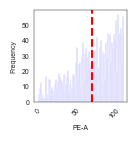

Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Mean PE fluorescence intensity after gating: 74.65


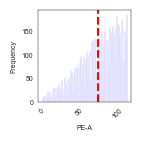

Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Mean PE fluorescence intensity after gating: 65.52


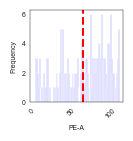

Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
Mean PE fluorescence intensity after gating: 57.06


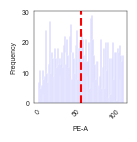

Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
Mean PE fluorescence intensity after gating: 65.90


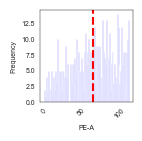

Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF8.fcs
Mean PE fluorescence intensity after gating: 63.98


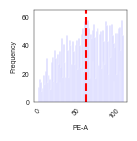

Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF17.fcs
Mean PE fluorescence intensity after gating: 61.84


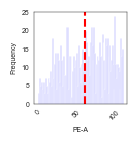

Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF8.fcs
Mean PE fluorescence intensity after gating: 59.41


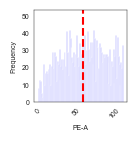

Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
Mean PE fluorescence intensity after gating: 28.58


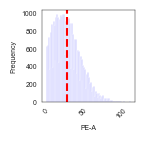

Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
Mean PE fluorescence intensity after gating: 28.32


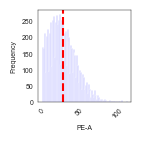

Processing... fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
Mean PE fluorescence intensity after gating: 75.47


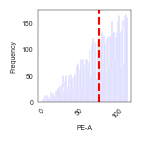

Processing... fcs_files/210609 clinical FACS/Controls_FMO L,2f,D.fcs
Mean PE fluorescence intensity after gating: 73.85


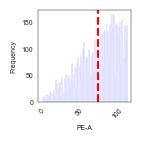

Processing... fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
Mean PE fluorescence intensity after gating: 70.66


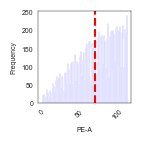

Processing... fcs_files/210609 clinical FACS/Controls_Fully unstained.fcs
Mean PE fluorescence intensity after gating: 27.82


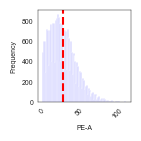

Processing... fcs_files/210609 clinical FACS/Controls_Unstain + L,2f,D.fcs
Mean PE fluorescence intensity after gating: 28.21


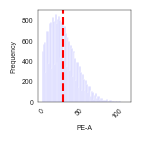

Processing... fcs_files/210609 clinical FACS/Controls_dFB fully stained.fcs
Mean PE fluorescence intensity after gating: 30.42


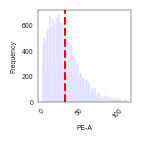

Processing... fcs_files/211021 clinical FACS follow-up/Alison B1_rVM.fcs
Mean PE fluorescence intensity after gating: 207.03


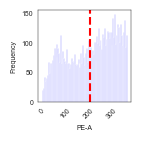

Processing... fcs_files/211021 clinical FACS follow-up/Alison B2_cVM.fcs
Mean PE fluorescence intensity after gating: 203.30


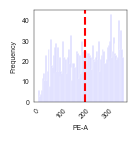

Processing... fcs_files/211021 clinical FACS follow-up/Alison B2_rVM.fcs
Mean PE fluorescence intensity after gating: 208.39


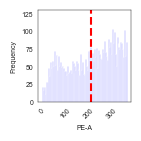

Processing... fcs_files/211021 clinical FACS follow-up/Batch for Tx_H9 cVM.fcs
Mean PE fluorescence intensity after gating: 153.57


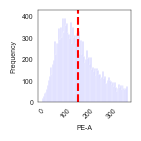

Processing... fcs_files/211021 clinical FACS follow-up/Batch for Tx_H9 rVM.fcs
Mean PE fluorescence intensity after gating: 227.55


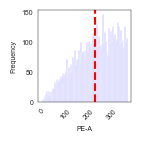

Processing... fcs_files/211021 clinical FACS follow-up/Batch for Tx_LatVM.fcs
Mean PE fluorescence intensity after gating: 215.90


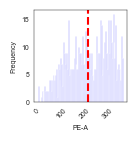

Processing... fcs_files/211021 clinical FACS follow-up/Batch for Tx_dMB+FGF8.fcs
Mean PE fluorescence intensity after gating: 138.41


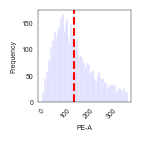

Processing... fcs_files/211021 clinical FACS follow-up/Controls_FMO APCDD1.fcs
Mean PE fluorescence intensity after gating: 32.18


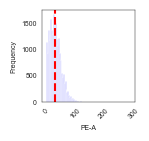

Processing... fcs_files/211021 clinical FACS follow-up/Controls_FMO FOXA2.fcs
Mean PE fluorescence intensity after gating: 202.22


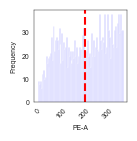

Processing... fcs_files/211021 clinical FACS follow-up/Controls_FMO L,2f,D.fcs
Mean PE fluorescence intensity after gating: 208.48


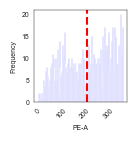

Processing... fcs_files/211021 clinical FACS follow-up/Controls_FMO OTX2.fcs
Mean PE fluorescence intensity after gating: 203.23


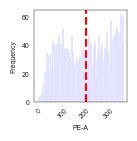

Processing... fcs_files/211021 clinical FACS follow-up/Controls_Fully unstained.fcs
Mean PE fluorescence intensity after gating: 32.23


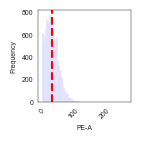

Processing... fcs_files/211021 clinical FACS follow-up/Controls_Unstain + L,2f,D.fcs
Mean PE fluorescence intensity after gating: 31.29


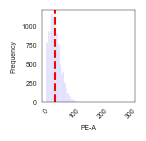

Processing... fcs_files/211021 clinical FACS follow-up/Controls_dHB fully stained.fcs
Mean PE fluorescence intensity after gating: 69.87


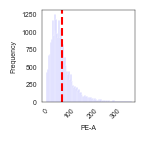

,filename,num_events,ssc_gate_events,live_gate_events,pct_foxa2,pct_otx2,pct_apcdd1,pct_double_foxa2_otx2,pct_foxa2_otx2_in_apcdd1_pos,pct_foxa2_otx2_in_apcdd1_neg,pct_apcdd1_in_foxas_otx2_pos,pct_apcdd1_in_foxas_otx2_neg,pct_foxa2_in_apcdd1,pct_otx2_in_apcdd1,pct_foxa2_in_apcdd1_neg,pct_otx2_in_apcdd1_neg,pct_triple,mfi_apcdd1,folder
0,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,40646,35623,33138,51.207073,70.858229,72.330859,50.724244,51.504026,48.685789,73.442799,26.557201,51.741833,69.886103,49.809139,73.399498,37.253304,71.930414,210609 clinical FACS
1,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,43300,38461,36693,36.696373,59.995094,40.996920,35.802469,32.207671,38.300231,36.880566,63.119434,32.805956,57.800971,39.399538,61.519630,13.204153,74.652848,210609 clinical FACS
2,fcs_files/210609 clinical FACS/AR25_CNUR_cVM +...,41780,37817,34279,83.383413,92.695236,98.477202,83.202544,84.341026,9.578544,99.824691,0.175309,84.515804,92.724472,10.153257,90.804598,83.056682,65.521919,210609 clinical FACS
3,fcs_files/210609 clinical FACS/AR25_CNUR_cVM +...,125576,115219,34408,83.471867,95.838177,92.539526,83.192862,88.100248,22.321776,97.998253,2.001747,88.313809,96.143337,23.412544,92.052980,81.527552,57.063368,210609 clinical FACS
4,fcs_files/210609 clinical FACS/AR26_CNUR_cVM +...,143203,124715,35961,87.441951,92.947916,96.070743,87.069325,88.971865,40.552017,98.169972,1.830028,89.203427,93.157346,44.373673,87.827318,85.475932,65.899746,210609 clinical FACS


In [ ]:
todays_date = datetime.datetime.now().strftime('%Y%m%d')
samples_skip = ['Compensation', 'SS']

data = []
for folder, files in imported_files.items():
    for filename, s in files.items():
        #remove specific samples
        if any(sample in filename for sample in samples_skip):
            continue
        if '210603' in filename:  #exclude the 210603 pilot experiment
            continue
        if s.shape[0] <= 1:
            continue

        print(f"Processing... {filename}")

        try:
            #apply gating
            if '210609' in filename:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
            else:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'],center=(1e5, 3e4), a=2e4, b=6e4,theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'],gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

            if g4.shape[0] < 10:
                print(f"Skipping {filename} due to too few live events after DAPI gating ({g4.shape[0]}).")
                continue

            #count events after various gates
            num_events = g1.shape[0]
            ssc_gate_events = g3.shape[0]
            live_gate_events = g4.shape[0]

            #retrieve fluorophore-specific cutoffs from the control dictionary
            for fluorophore in ['PE', 'FITC', 'APC']:
                cutoff = std_cutoffs_mix[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    continue

            #define cutoffs (by convention)
            foxa2_cutoff = std_cutoffs_mix[folder]['FITC']
            otx2_cutoff  = std_cutoffs_mix[folder]['APC']
            apcdd1_cutoff = std_cutoffs_mix[folder]['PE']

            #extract channel data from the live gate (g4)
            foxa2_data = g4[:, g4.channels.index('FITC-A')].astype('<f8')
            otx2_data  = g4[:, g4.channels.index('APC-A')].astype('<f8')
            apcdd1_data = g4[:, g4.channels.index('PE-A')].astype('<f8')

            #create single-channel masks
            foxa2_pos_mask = foxa2_data > foxa2_cutoff
            otx2_pos_mask  = otx2_data > otx2_cutoff
            apcdd1_pos_mask = apcdd1_data > apcdd1_cutoff
            apcdd1_neg_mask = apcdd1_data <= apcdd1_cutoff

            #count single-positive events
            num_foxa2_pos  = np.sum(foxa2_pos_mask)
            num_otx2_pos   = np.sum(otx2_pos_mask)
            num_apcdd1_pos = np.sum(apcdd1_pos_mask)
            num_apcdd1_neg = np.sum(apcdd1_neg_mask)

            #create a double-positive mask for FOXA2 and OTX2 (of live events)
            double_mask_foxa2_otx2 = (foxa2_data > foxa2_cutoff) & (otx2_data > otx2_cutoff)
            num_double_foxa2_otx2 = np.sum(double_mask_foxa2_otx2)

            #1. FOXA2+OTX2+ within APCDD1+

            #1.1. APCDD1+ events: calculate the fraction that are FOXA2+OTX2+.
            foxa2_otx2_in_apcdd1_pos = ((foxa2_data[apcdd1_pos_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_pos_mask] > otx2_cutoff))
            num_double_in_apcdd1_pos = np.sum(foxa2_otx2_in_apcdd1_pos)
            pct_foxa2_otx2_in_apcdd1_pos = (num_double_in_apcdd1_pos / num_apcdd1_pos * 100) if num_apcdd1_pos > 0 else 0

            #1.2. APCDD1– events: calculate the fraction that are FOXA2+OTX2+
            foxa2_otx2_in_apcdd1_neg = ((foxa2_data[apcdd1_neg_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_neg_mask] > otx2_cutoff))
            num_double_in_apcdd1_neg = np.sum(foxa2_otx2_in_apcdd1_neg)
            pct_foxa2_otx2_in_apcdd1_neg = (num_double_in_apcdd1_neg / num_apcdd1_neg * 100) if num_apcdd1_neg > 0 else 0


            #2. APCDD1 within FOXA2+OTX2+
            #FOXA2+OTX2+ events: determine APCDD1+ vs APCDD1–
            #we already have double_mask_foxa2_otx2 covering all FOXA2+OTX2+ events
            num_double = num_double_foxa2_otx2  #total FOXA2+OTX2+ events
            apcdd1_in_double = apcdd1_data[double_mask_foxa2_otx2]
            num_apcdd1_in_double_pos = np.sum(apcdd1_in_double > apcdd1_cutoff)
            num_apcdd1_in_double_neg = np.sum(apcdd1_in_double <= apcdd1_cutoff)
            pct_apcdd1_in_double_pos = (num_apcdd1_in_double_pos / num_double * 100) if num_double > 0 else 0
            pct_apcdd1_in_double_neg = (num_apcdd1_in_double_neg / num_double * 100) if num_double > 0 else 0

            #3. Individual gating within APCDD1
            #3.1 APCDD1+: FOXA2 and OTX2 individually:
            foxa2_in_apcdd1_pos = foxa2_data[apcdd1_pos_mask]
            otx2_in_apcdd1_pos = otx2_data[apcdd1_pos_mask]
            num_foxa2_in_apcdd1_pos = np.sum(foxa2_in_apcdd1_pos > foxa2_cutoff)
            num_otx2_in_apcdd1_pos = np.sum(otx2_in_apcdd1_pos > otx2_cutoff)

            #3.2 APCDD1–: FOXA2 and OTX2 individually:
            foxa2_in_apcdd1_neg = foxa2_data[apcdd1_neg_mask]
            otx2_in_apcdd1_neg = otx2_data[apcdd1_neg_mask]
            num_foxa2_in_apcdd1_neg = np.sum(foxa2_in_apcdd1_neg > foxa2_cutoff)
            num_otx2_in_apcdd1_neg = np.sum(otx2_in_apcdd1_neg > otx2_cutoff)

            #4. FOXA2+OTX2+APCDD+
            triple_mask = (foxa2_data > foxa2_cutoff) & (otx2_data > otx2_cutoff) & (apcdd1_data > apcdd1_cutoff)
            num_triple = np.sum(triple_mask)

            #live cells
            live_events = live_gate_events

            #overall percentages relative to live events
            pct_foxa2 = (num_foxa2_pos / live_events) * 100
            pct_otx2 = (num_otx2_pos / live_events) * 100
            pct_apcdd1 = (num_apcdd1_pos / live_events) * 100
            pct_double_foxa2_otx2 = (num_double_foxa2_otx2 / live_events) * 100

            #subpopulation percentages (within APCDD1+ and APCDD1-)
            pct_foxa2_in_apcdd1 = (num_foxa2_in_apcdd1_pos / num_apcdd1_pos * 100) if num_apcdd1_pos > 0 else 0
            pct_otx2_in_apcdd1 = (num_otx2_in_apcdd1_pos / num_apcdd1_pos * 100) if num_apcdd1_pos > 0 else 0
            pct_foxa2_in_apcdd1_neg = (num_foxa2_in_apcdd1_neg / num_apcdd1_neg * 100) if num_apcdd1_neg > 0 else 0
            pct_otx2_in_apcdd1_neg = (num_otx2_in_apcdd1_neg / num_apcdd1_neg * 100) if num_apcdd1_neg > 0 else 0

            pct_triple = (num_triple / live_events) * 100


            #set gate based on ctrl_perc_cutoffs PE cutoff
            cutoff = ctrl_perc_cutoffs[folder].get('PE', None)
            g5 = FlowCal.gate.high_low(g4, channels=['PE-A'], high=ctrl_perc_cutoffs[folder]['PE'])

            #calculate the mean fluorescence intensity of the PE channel after gating
            mfi_pe = np.mean(g5[:, g5.channels.index('PE-A')].astype('<f8'))
            print(f"Mean PE fluorescence intensity after gating: {mfi_pe:.2f}")


            #append all metrics to the results dictionary
            data.append({
                'filename': filename,
                'num_events': num_events,
                'ssc_gate_events': ssc_gate_events,
                'live_gate_events': live_gate_events,
                'pct_foxa2': pct_foxa2,
                'pct_otx2': pct_otx2,
                'pct_apcdd1': pct_apcdd1,
                'pct_double_foxa2_otx2': pct_double_foxa2_otx2,
                
                #FOXA2+OTX2+ within APCDD1+ vs APCDD1-:
                'pct_foxa2_otx2_in_apcdd1_pos': pct_foxa2_otx2_in_apcdd1_pos,
                'pct_foxa2_otx2_in_apcdd1_neg': pct_foxa2_otx2_in_apcdd1_neg,
                
                #APCDD1 within FOXA2+OTX2+:
                'pct_apcdd1_in_foxas_otx2_pos': pct_apcdd1_in_double_pos,
                'pct_apcdd1_in_foxas_otx2_neg': pct_apcdd1_in_double_neg,
                
                #additional individual gating within APCDD1+ and APCDD1-:
                'pct_foxa2_in_apcdd1': pct_foxa2_in_apcdd1,
                'pct_otx2_in_apcdd1': pct_otx2_in_apcdd1,
                'pct_foxa2_in_apcdd1_neg': pct_foxa2_in_apcdd1_neg,
                'pct_otx2_in_apcdd1_neg': pct_otx2_in_apcdd1_neg,
                'pct_triple': pct_triple,

                #mfi 
                'mfi_apcdd1': mfi_pe,

                'folder': folder
            })

        except ValueError as e:
            print(f"Error processing {filename}: {e}")

#create, view and save
nn = pd.DataFrame(data)
nn.to_csv(f"output/flow py nn panel {todays_date}.csv", index=False)
nn.head()

### Clean the data

In [ ]:
#read the nn dataframe
todays_date = datetime.datetime.now().strftime('%Y%m%d')
nn = pd.read_csv(f"output/flow py nn panel {todays_date}.csv")
#nn = pd.read_csv('output/flow py nn panel yyymmdd.csv') #alternatively

#remove 'fcs_files/' from the filename column
nn['filename'] = nn['filename'].str.replace('fcs_files/', '')

#calculate the percentage of positive cells
event_types = ['live_gate_events']

for event in event_types:
    nn[f'pct_{event}'] = 100 * (nn[event] / nn['ssc_gate_events'])

#remove the num_events an ssc_gate_events cols
nn = nn.drop(columns=['num_events', 'ssc_gate_events', 'live_gate_events'])

nn.head()

,filename,pct_foxa2,pct_otx2,pct_apcdd1,pct_double_foxa2_otx2,pct_foxa2_otx2_in_apcdd1_pos,pct_foxa2_otx2_in_apcdd1_neg,pct_apcdd1_in_foxas_otx2_pos,pct_apcdd1_in_foxas_otx2_neg,pct_foxa2_in_apcdd1,pct_otx2_in_apcdd1,pct_foxa2_in_apcdd1_neg,pct_otx2_in_apcdd1_neg,pct_triple,mfi_apcdd1,folder,pct_live_gate_events
0,210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs,51.207073,70.858229,72.330859,50.724244,51.504026,48.685789,73.442799,26.557201,51.741833,69.886103,49.809139,73.399498,37.253304,71.930414,210609 clinical FACS,93.024170
1,210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs,36.696373,59.995094,40.996920,35.802469,32.207671,38.300231,36.880566,63.119434,32.805956,57.800971,39.399538,61.519630,13.204153,74.652848,210609 clinical FACS,95.403136
2,210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs,83.383413,92.695236,98.477202,83.202544,84.341026,9.578544,99.824691,0.175309,84.515804,92.724472,10.153257,90.804598,83.056682,65.521919,210609 clinical FACS,90.644419
3,210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs,83.471867,95.838177,92.539526,83.192862,88.100248,22.321776,97.998253,2.001747,88.313809,96.143337,23.412544,92.052980,81.527552,57.063368,210609 clinical FACS,29.863130
4,210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs,87.441951,92.947916,96.070743,87.069325,88.971865,40.552017,98.169972,1.830028,89.203427,93.157346,44.373673,87.827318,85.475932,65.899746,210609 clinical FACS,28.834543


In [ ]:
#change the column order so that filename is first, and then the folder 
#get current columns as a list
cols = list(nn.columns)

#remove the columns to reposition
cols.remove('filename')
cols.remove('folder')

#create a new order: filename first, folder second, then the rest
new_order = ['filename', 'folder'] + cols

#reorder
nn = nn[new_order]
nn.head()

,filename,folder,pct_foxa2,pct_otx2,pct_apcdd1,pct_double_foxa2_otx2,pct_foxa2_otx2_in_apcdd1_pos,pct_foxa2_otx2_in_apcdd1_neg,pct_apcdd1_in_foxas_otx2_pos,pct_apcdd1_in_foxas_otx2_neg,pct_foxa2_in_apcdd1,pct_otx2_in_apcdd1,pct_foxa2_in_apcdd1_neg,pct_otx2_in_apcdd1_neg,pct_triple,mfi_apcdd1,pct_live_gate_events
0,210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs,210609 clinical FACS,51.207073,70.858229,72.330859,50.724244,51.504026,48.685789,73.442799,26.557201,51.741833,69.886103,49.809139,73.399498,37.253304,71.930414,93.024170
1,210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs,210609 clinical FACS,36.696373,59.995094,40.996920,35.802469,32.207671,38.300231,36.880566,63.119434,32.805956,57.800971,39.399538,61.519630,13.204153,74.652848,95.403136
2,210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs,210609 clinical FACS,83.383413,92.695236,98.477202,83.202544,84.341026,9.578544,99.824691,0.175309,84.515804,92.724472,10.153257,90.804598,83.056682,65.521919,90.644419
3,210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs,210609 clinical FACS,83.471867,95.838177,92.539526,83.192862,88.100248,22.321776,97.998253,2.001747,88.313809,96.143337,23.412544,92.052980,81.527552,57.063368,29.863130
4,210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs,210609 clinical FACS,87.441951,92.947916,96.070743,87.069325,88.971865,40.552017,98.169972,1.830028,89.203427,93.157346,44.373673,87.827318,85.475932,65.899746,28.834543


In [ ]:
#pivot the the pct columns longer
nn_long = nn.melt(id_vars=['filename', 'folder'],
                  #value_vars=[col for col in nn.columns if col.startswith('pct_')],
                  var_name='gate', 
                  value_name='value')

#inspect
print(nn_long['gate'].unique())


#remove everything before the first '/' in the filename
nn_long['filename'] = nn_long['filename'].str.split('/').str[-1]

#inspect
nn_long.head()

['pct_foxa2' 'pct_otx2' 'pct_apcdd1' 'pct_double_foxa2_otx2'
 'pct_foxa2_otx2_in_apcdd1_pos' 'pct_foxa2_otx2_in_apcdd1_neg'
 'pct_apcdd1_in_foxas_otx2_pos' 'pct_apcdd1_in_foxas_otx2_neg'
 'pct_foxa2_in_apcdd1' 'pct_otx2_in_apcdd1' 'pct_foxa2_in_apcdd1_neg'
 'pct_otx2_in_apcdd1_neg' 'pct_triple' 'mfi_apcdd1' 'pct_live_gate_events']


,filename,folder,gate,value
0,210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs,210609 clinical FACS,pct_foxa2,51.207073
1,210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs,210609 clinical FACS,pct_foxa2,36.696373
2,210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs,210609 clinical FACS,pct_foxa2,83.383413
3,210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs,210609 clinical FACS,pct_foxa2,83.471867
4,210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs,210609 clinical FACS,pct_foxa2,87.441951


In [ ]:
#get unique values in the filename column
print(f"pre-filtering:\n {nn_long['filename'].unique()}")

#filter out samples that contain one of the strings in the samples_remove list
samples_remove = ['Controls_FMO', 'Controls_Unstain', 'Controls_Fully unstained']
nn_long = nn_long[~nn_long['filename'].str.contains('|'.join(samples_remove))]

#check that it worked
print(f"post-filtering:\n {nn_long['filename'].unique()}")

pre-filtering:
 ['AR24_CNUR_cVM + FGF17.fcs' 'AR24_CNUR_cVM + FGF8.fcs'
 'AR25_CNUR_cVM + FGF17.fcs' 'AR25_CNUR_cVM + FGF8.fcs'
 'AR26_CNUR_cVM + FGF17.fcs' 'AR26_CNUR_cVM + FGF8.fcs'
 'CR33_CNUR_cVM + FGF17.fcs' 'CR33_CNUR_cVM + FGF8.fcs'
 'Controls_FMO APCDD1.fcs' 'Controls_FMO APCDD1_001.fcs'
 'Controls_FMO FOXA2.fcs' 'Controls_FMO L,2f,D.fcs'
 'Controls_FMO OTX2.fcs' 'Controls_Fully unstained.fcs'
 'Controls_Unstain + L,2f,D.fcs' 'Controls_dFB fully stained.fcs'
 'Alison B1_rVM.fcs' 'Alison B2_cVM.fcs' 'Alison B2_rVM.fcs'
 'Batch for Tx_H9 cVM.fcs' 'Batch for Tx_H9 rVM.fcs'
 'Batch for Tx_LatVM.fcs' 'Batch for Tx_dMB+FGF8.fcs'
 'Controls_dHB fully stained.fcs']
post-filtering:
 ['AR24_CNUR_cVM + FGF17.fcs' 'AR24_CNUR_cVM + FGF8.fcs'
 'AR25_CNUR_cVM + FGF17.fcs' 'AR25_CNUR_cVM + FGF8.fcs'
 'AR26_CNUR_cVM + FGF17.fcs' 'AR26_CNUR_cVM + FGF8.fcs'
 'CR33_CNUR_cVM + FGF17.fcs' 'CR33_CNUR_cVM + FGF8.fcs'
 'Controls_dFB fully stained.fcs' 'Alison B1_rVM.fcs' 'Alison B2_cVM.fcs'
 'Alison B2

In [23]:
#save the dataframe
nn_long.to_csv(f"output/flow py nn panel long {todays_date}.csv", index=False)

#read the dataframe
todays_date = datetime.datetime.now().strftime('%Y%m%d')
nn_long = pd.read_csv(f"output/flow py nn panel long {todays_date}.csv")
#nn_long = pd.read_csv('output/flow py nn panel long yyymmdd.csv') #alternatively

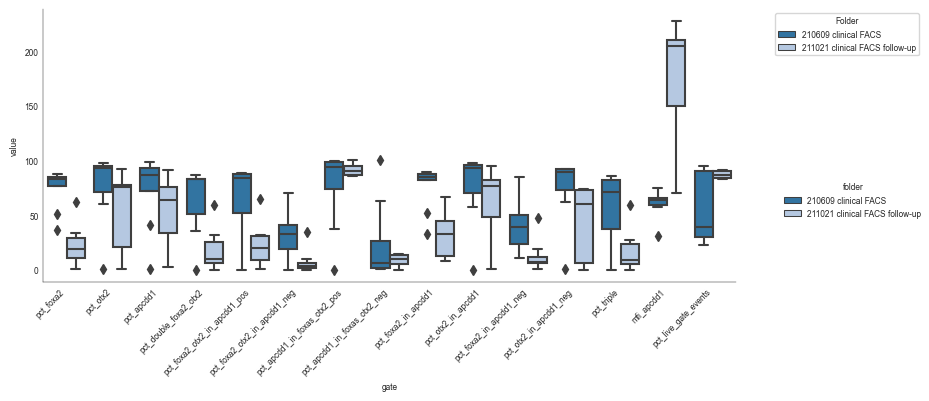

In [24]:
#plot the percentage of positive cells
custom_theme_6pt()

g = sns.catplot(data=nn_long, x='gate', y='value', hue='folder', kind='box', height=4, aspect=1.5, palette='tab20')
#g.set(yscale='log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Folder', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.savefig(f"output/flow py nn panel {todays_date}.pdf", dpi=150)
plt.show()

# Calculate sensitivity and specificity

## Cell-level (binary)

In [ ]:
todays_date = datetime.datetime.now().strftime('%Y%m%d')
samples_skip = ['Compensation', 'SS']

data = []
for folder, files in imported_files.items():
    for filename, s in files.items():
        #remove specific samples
        if any(sample in filename for sample in samples_skip):
            continue
        if '210603' in filename:
            continue
        if s.shape[0] <= 1:
            continue

        print(f"Processing... {filename}")

        try:
            #apply gating steps
            if '210609' in filename:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
            else:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'],center=(1e5, 3e4), a=2e4, b=6e4,theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'],gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

            if g4.shape[0] < 10:
                print(f"Skipping {filename} due to too few live events after DAPI gating ({g4.shape[0]}).")
                continue

            #count events
            num_events = g1.shape[0]
            ssc_gate_events = g3.shape[0]
            live_gate_events = g4.shape[0]

            for fluorophore in ['PE', 'FITC', 'APC']:
                cutoff = std_cutoffs_mix[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    continue

            #define cutoffs (by convention)
            foxa2_cutoff = std_cutoffs_mix[folder]['FITC']
            otx2_cutoff  = std_cutoffs_mix[folder]['APC']
            apcdd1_cutoff = std_cutoffs_mix[folder]['PE']

            #extract channel data
            foxa2_data = g4[:, g4.channels.index('FITC-A')].astype('<f8')
            otx2_data  = g4[:, g4.channels.index('APC-A')].astype('<f8')
            apcdd1_data = g4[:, g4.channels.index('PE-A')].astype('<f8')

            #create single-channel masks
            foxa2_pos_mask = foxa2_data > foxa2_cutoff
            otx2_pos_mask  = otx2_data > otx2_cutoff
            apcdd1_pos_mask = apcdd1_data > apcdd1_cutoff
            apcdd1_neg_mask = apcdd1_data <= apcdd1_cutoff

            #count single-positive events
            num_foxa2_pos  = np.sum(foxa2_pos_mask)
            num_otx2_pos   = np.sum(otx2_pos_mask)
            num_apcdd1_pos = np.sum(apcdd1_pos_mask)
            num_apcdd1_neg = np.sum(apcdd1_neg_mask)

            #create double-positive mask for FOXA2 and OTX2 over all live events
            double_mask_foxa2_otx2 = (foxa2_data > foxa2_cutoff) & (otx2_data > otx2_cutoff)
            num_double_foxa2_otx2 = np.sum(double_mask_foxa2_otx2)

            #create non-double mask for FOXA2 and OTX2 over all live events
            not_double_mask_foxa2_otx2 = ~double_mask_foxa2_otx2
            num_double = num_double_foxa2_otx2  # Total FOXA2⁺OTX2⁺ events
            num_not_double_foxa2_otx2 = np.sum(not_double_mask_foxa2_otx2)

            #calculate confusion matrix metrics
            #true positives
            foxa2_otx2_in_apcdd1_pos = ((foxa2_data[apcdd1_pos_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_pos_mask] > otx2_cutoff))
            num_double_in_apcdd1_pos = np.sum(foxa2_otx2_in_apcdd1_pos)


            #false negatives
            foxa2_otx2_in_apcdd1_neg = ((foxa2_data[apcdd1_neg_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_neg_mask] > otx2_cutoff))
            num_double_in_apcdd1_neg = np.sum(foxa2_otx2_in_apcdd1_neg)


            #false positives (apcdd1_pos in !double_foxa2_otx2_pos)
            apcdd1_pos_in_not_double_foxa2_otx2 = apcdd1_data[not_double_mask_foxa2_otx2]
            num_apcdd1_pos_in_not_double_foxa2_otx2 = np.sum(apcdd1_pos_in_not_double_foxa2_otx2 > apcdd1_cutoff)
            num_apcdd1_neg_in_not_double_foxa2_otx2 = np.sum(apcdd1_pos_in_not_double_foxa2_otx2 <= apcdd1_cutoff)
            
            apcdd1_in_double = apcdd1_data[double_mask_foxa2_otx2]

            #false positives
            num_apcdd1_in_double_pos = np.sum(apcdd1_in_double > apcdd1_cutoff)


            num_apcdd1_pos_in_double_pos = np.sum(apcdd1_in_double > apcdd1_cutoff)
            num_apcdd1_neg_in_double_neg = np.sum(apcdd1_in_double <= apcdd1_cutoff)


                                #apcdd1_pos                                          apcdd1_neg
#double_foxa2_otx2_pos          true_pos=double_foxa2_otx2_pos in apcdd1_pos         false_neg= double_foxa2_otx2_pos in apcdd1_neg
#not double_foxa2_otx2_pos      false_pos=apcdd1_pos in !double_foxa2_otx2_pos       true_neg= apcdd1_neg in !double_foxa2_otx2_pos



            #append all metric
            data.append({
                #basic info
                'folder': folder,
                'filename': filename,
                'num_events': num_events,

                #confusion matrix metrics
                'num_true_pos': num_double_in_apcdd1_pos,
                'num_false_neg': num_double_in_apcdd1_neg,
                'num_false_pos': num_apcdd1_pos_in_not_double_foxa2_otx2,
                'num_true_neg': num_apcdd1_neg_in_not_double_foxa2_otx2

            })

        except ValueError as e:
            print(f"Error processing {filename}: {e}")

#inspect and save df
nn_conf = pd.DataFrame(data)
nn_conf.to_csv(f"output/flow py nn panel sens spec {todays_date}.csv", index=False)
nn_conf.head()

Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO L,2f,D.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
Processing... fcs_files/210609 clinical FACS/Controls_Fully unstained.fcs
Processing... fc

,folder,filename,num_events,num_true_pos,num_false_neg,num_false_pos,num_true_neg
0,210609 clinical FACS,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,40646,12345,4464,11624,4705
1,210609 clinical FACS,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,43300,4845,8292,10198,13358
2,210609 clinical FACS,fcs_files/210609 clinical FACS/AR25_CNUR_cVM +...,41780,28471,50,5286,472
3,210609 clinical FACS,fcs_files/210609 clinical FACS/AR25_CNUR_cVM +...,125576,28052,573,3789,1994
4,210609 clinical FACS,fcs_files/210609 clinical FACS/AR26_CNUR_cVM +...,143203,30738,573,3810,840


In [ ]:
###clean

#read the nn dataframe
todays_date = datetime.datetime.now().strftime('%Y%m%d')
nn_conf = pd.read_csv(f"output/flow py nn panel sens spec {todays_date}.csv")
#nn = pd.read_csv('output/flow py nn panel yyymmdd.csv') #alternatively

#remove 'fcs_files/' from the filename column
nn_conf['filename'] = nn_conf['filename'].str.replace('fcs_files/', '')

#remove everything before the first '/' in the filename
nn_conf['filename'] = nn_conf['filename'].str.split('/').str[-1]

#remove the num_events an ssc_gate_events cols
nn_conf = nn_conf.drop(columns=['num_events'])

nn_conf.head()

,folder,filename,num_true_pos,num_false_neg,num_false_pos,num_true_neg
0,210609 clinical FACS,AR24_CNUR_cVM + FGF17.fcs,12345,4464,11624,4705
1,210609 clinical FACS,AR24_CNUR_cVM + FGF8.fcs,4845,8292,10198,13358
2,210609 clinical FACS,AR25_CNUR_cVM + FGF17.fcs,28471,50,5286,472
3,210609 clinical FACS,AR25_CNUR_cVM + FGF8.fcs,28052,573,3789,1994
4,210609 clinical FACS,AR26_CNUR_cVM + FGF17.fcs,30738,573,3810,840


## Intensity-based (continous)

In [ ]:
todays_date = datetime.datetime.now().strftime('%Y%m%d')
samples_skip = ['Compensation', 'SS']

cell_level_data = []
for folder, files in imported_files.items():
    for filename, s in files.items():
        #remove specific samples
        if any(sample in filename for sample in samples_skip):
            continue
        if '210603' in filename:  #exclude the 210603 pilot experiment
            continue
        if s.shape[0] <= 1:
            continue

        print(f"Processing... {filename}")

        try:
            #gating
            if '210609' in filename:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(9.3e4, 3e4), a=2e4, b=6e4, theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)
            else:
                g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'],center=(1e5, 3e4), a=2e4, b=6e4,theta=-75/180.*np.pi)
                g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'],gate_fraction=0.96)
                g3 = FlowCal.gate.ellipse(g2, channels=['SSC-H', 'SSC-W'],center=(7e4, 8e4), a=2e4, b=2e5)
                g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=3e3)

            if g4.shape[0] < 10:
                print(f"Skipping {filename} due to too few live events after DAPI gating ({g4.shape[0]}).")
                continue

            #count events
            num_events = g1.shape[0]
            ssc_gate_events = g3.shape[0]
            live_gate_events = g4.shape[0]

            #retrieve fluorophore-specific cutoffs
            for fluorophore in ['PE', 'FITC', 'APC']:
                cutoff = std_cutoffs_mix[folder].get(fluorophore, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluorophore} in folder: {folder}")
                    continue

            #define cutoffs
            foxa2_cutoff = std_cutoffs_mix[folder]['FITC']
            otx2_cutoff  = std_cutoffs_mix[folder]['APC']
            apcdd1_cutoff = std_cutoffs_mix[folder]['PE']

            #extract channel data
            foxa2_data = g4[:, g4.channels.index('FITC-A')].astype('<f8')
            otx2_data  = g4[:, g4.channels.index('APC-A')].astype('<f8')
            apcdd1_data = g4[:, g4.channels.index('PE-A')].astype('<f8')

            #create single-channel masks
            foxa2_pos_mask = foxa2_data > foxa2_cutoff
            otx2_pos_mask  = otx2_data > otx2_cutoff
            apcdd1_pos_mask = apcdd1_data > apcdd1_cutoff
            apcdd1_neg_mask = apcdd1_data <= apcdd1_cutoff

            #count single-positive events
            num_foxa2_pos  = np.sum(foxa2_pos_mask)
            num_otx2_pos   = np.sum(otx2_pos_mask)
            num_apcdd1_pos = np.sum(apcdd1_pos_mask)
            num_apcdd1_neg = np.sum(apcdd1_neg_mask)

            #create a double-positive mask for FOXA2 and OTX2 over all live events
            double_mask_foxa2_otx2 = (foxa2_data > foxa2_cutoff) & (otx2_data > otx2_cutoff)
            num_double_foxa2_otx2 = np.sum(double_mask_foxa2_otx2)

            #create a non-double mask for FOXA2 and OTX2 over all live events
            not_double_mask_foxa2_otx2 = ~double_mask_foxa2_otx2
            num_double = num_double_foxa2_otx2  # Total FOXA2⁺OTX2⁺ events
            num_not_double_foxa2_otx2 = np.sum(not_double_mask_foxa2_otx2)

            #determine  parametrics for confusion matrix/ ROC curve
            #true positives
            foxa2_otx2_in_apcdd1_pos = ((foxa2_data[apcdd1_pos_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_pos_mask] > otx2_cutoff))
            num_double_in_apcdd1_pos = np.sum(foxa2_otx2_in_apcdd1_pos)


            #false negatives
            foxa2_otx2_in_apcdd1_neg = ((foxa2_data[apcdd1_neg_mask] > foxa2_cutoff) &
                                        (otx2_data[apcdd1_neg_mask] > otx2_cutoff))
            num_double_in_apcdd1_neg = np.sum(foxa2_otx2_in_apcdd1_neg)


            #false positives (apcdd1_pos in !double_foxa2_otx2_pos)
            apcdd1_pos_in_not_double_foxa2_otx2 = apcdd1_data[not_double_mask_foxa2_otx2]
            num_apcdd1_pos_in_not_double_foxa2_otx2 = np.sum(apcdd1_pos_in_not_double_foxa2_otx2 > apcdd1_cutoff)
            num_apcdd1_neg_in_not_double_foxa2_otx2 = np.sum(apcdd1_pos_in_not_double_foxa2_otx2 <= apcdd1_cutoff)
            
            apcdd1_in_double = apcdd1_data[double_mask_foxa2_otx2]

            #false positives
            num_apcdd1_in_double_pos = np.sum(apcdd1_in_double > apcdd1_cutoff)


            num_apcdd1_pos_in_double_pos = np.sum(apcdd1_in_double > apcdd1_cutoff)
            num_apcdd1_neg_in_double_neg = np.sum(apcdd1_in_double <= apcdd1_cutoff)


                                #apcdd1_pos                                          apcdd1_neg
#double_foxa2_otx2_pos          true_pos=double_foxa2_otx2_pos in apcdd1_pos         false_neg= double_foxa2_otx2_pos in apcdd1_neg
#not double_foxa2_otx2_pos      false_pos=apcdd1_pos in !double_foxa2_otx2_pos       true_neg= apcdd1_neg in !double_foxa2_otx2_pos



            #append metrics
            for intensity, is_foxa2_otx2 in zip(apcdd1_data, double_mask_foxa2_otx2):
                cell_level_data.append({
                # Add per-cell data for ROC analysis
                'filename': filename,
                'folder': folder,
                'apcdd1_intensity': intensity,
                'is_vm': is_foxa2_otx2  # True if FOXA2+OTX2+, else False
    })

        except ValueError as e:
            print(f"Error processing {filename}: {e}")

#save df
nn_conf_cell_lvl = pd.DataFrame(cell_level_data)
nn_conf_cell_lvl.to_csv(f"output/flow py nn panel sens spec cell level {todays_date}.csv", index=False)
nn_conf_cell_lvl.head()

Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR24_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR25_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/AR26_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF17.fcs
Processing... fcs_files/210609 clinical FACS/CR33_CNUR_cVM + FGF8.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO APCDD1_001.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO FOXA2.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO L,2f,D.fcs
Processing... fcs_files/210609 clinical FACS/Controls_FMO OTX2.fcs
Processing... fcs_files/210609 clinical FACS/Controls_Fully unstained.fcs
Processing... fc

,filename,folder,apcdd1_intensity,is_vm
0,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,210609 clinical FACS,480.999969,True
1,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,210609 clinical FACS,464.099976,False
2,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,210609 clinical FACS,192.399994,False
3,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,210609 clinical FACS,662.349976,True
4,fcs_files/210609 clinical FACS/AR24_CNUR_cVM +...,210609 clinical FACS,480.999969,False


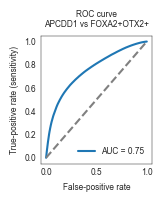

In [ ]:
#define the df
df = pd.DataFrame(cell_level_data)
df = df[df['folder'].str.contains('211021')] #include only the 211021 experiment
df = df[~df['filename'].str.contains('Controls|FMO|unstain|Unstain')] #exclude controls and FMOs
df = df.dropna(subset=['is_vm', 'apcdd1_intensity']) #remove NaNs and non-positive values before log transform

#transform and scale
df['apcdd1_z'] = df.groupby('folder')['apcdd1_intensity'].transform(
    lambda x: (x - x.mean()) / x.std())

df['apcdd1_scaled'] = df.groupby('folder')['apcdd1_intensity'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()))

#define true labels and scores for ROC analysis
y_true = df['is_vm']
y_scores = df['apcdd1_intensity']

#calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

#plot
plt.figure(figsize=(1.6, 2))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False-positive rate')
plt.ylabel('True-positive rate (sensitivity)')
plt.title('ROC curve\nAPCDD1 vs FOXA2+OTX2+')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()

plt.savefig(f"output/flow py nn panel apcdd1 roc curve.pdf", dpi=150)
plt.show()